In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import numpy as np
from aind_behavior_gym.dynamic_foraging.task import CoupledBlockTask, UncoupledBlockTask
from aind_dynamic_foraging_models.generative_model import ForagerCollection


from aind_dynamic_foraging_models.generative_model.foragers import ForagerCollection


forager_collection: ForagerCollection = ForagerCollection()
df = forager_collection.get_all_foragers()

df


,agent_class_name,agent_kwargs,agent_alias,number_of_learning_rate,number_of_forget_rate,choice_kernel,action_selection,preset_name,n_free_params,params,forager,win_stay_lose_switch,reset_to_threshold,include_stay_bias,include_side_bias,fix_threshold
0,ForagerQLearning,"{'number_of_learning_rate': 1, 'number_of_forg...",QLearning_L1F0_softmax,1.0,0.0,none,softmax,None,3,"$\alpha$, $b_L$, $\beta$",<aind_dynamic_foraging_models.generative_model...,NaN,NaN,NaN,NaN,NaN
1,ForagerQLearning,"{'number_of_learning_rate': 1, 'number_of_forg...",QLearning_L1F0_epsi,1.0,0.0,none,epsilon-greedy,Rescorla-Wagner,3,"$\alpha$, $b_L$, $\epsilon$",<aind_dynamic_foraging_models.generative_model...,NaN,NaN,NaN,NaN,NaN
2,ForagerQLearning,"{'number_of_learning_rate': 1, 'number_of_forg...",QLearning_L1F0_CK1_softmax,1.0,0.0,one_step,softmax,None,4,"$\alpha$, $\alpha_{ck}$ (fixed), $w_{ck}$, $b_...",<aind_dynamic_foraging_models.generative_model...,NaN,NaN,NaN,NaN,NaN
3,ForagerQLearning,"{'number_of_learning_rate': 1, 'number_of_forg...",QLearning_L1F0_CK1_epsi,1.0,0.0,one_step,epsilon-greedy,None,4,"$\alpha$, $\alpha_{ck}$ (fixed), $w_{ck}$, $b_...",<aind_dynamic_foraging_models.generative_model...,NaN,NaN,NaN,NaN,NaN
4,ForagerQLearning,"{'number_of_learning_rate': 1, 'number_of_forg...",QLearning_L1F0_CKfull_softmax,1.0,0.0,full,softmax,None,5,"$\alpha$, $\alpha_{ck}$, $w_{ck}$, $b_L$, $\beta$",<aind_dynamic_foraging_models.generative_model...,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,ForagerCompareThreshold,"{'number_of_learning_rate': 2, 'choice_kernel'...",ForagingCompareThreshold_L2_CKfull_ResetF_Stay...,2.0,NaN,full,NaN,None,7,"$\alpha_{rew}$, $\alpha_{unr}$, $\alpha_{ck}$,...",<aind_dynamic_foraging_models.generative_model...,NaN,False,True,False,False
122,ForagerCompareThreshold,"{'number_of_learning_rate': 2, 'choice_kernel'...",ForagingCompareThreshold_L2_CKfull_ResetF_Stay...,2.0,NaN,full,NaN,None,6,"$\alpha_{rew}$, $\alpha_{unr}$, $\alpha_{ck}$,...",<aind_dynamic_foraging_models.generative_model...,NaN,False,False,True,True
123,ForagerCompareThreshold,"{'number_of_learning_rate': 2, 'choice_kernel'...",ForagingCompareThreshold_L2_CKfull_ResetF_Stay...,2.0,NaN,full,NaN,None,7,"$\alpha_{rew}$, $\alpha_{unr}$, $\alpha_{ck}$,...",<aind_dynamic_foraging_models.generative_model...,NaN,False,False,True,False
124,ForagerCompareThreshold,"{'number_of_learning_rate': 2, 'choice_kernel'...",ForagingCompareThreshold_L2_CKfull_ResetF_Stay...,2.0,NaN,full,NaN,None,5,"$\alpha_{rew}$, $\alpha_{unr}$, $\alpha_{ck}$,...",<aind_dynamic_foraging_models.generative_model...,NaN,False,False,False,True


In [9]:
from __future__ import annotations

import copy
import itertools
import json
import re
from concurrent.futures import ProcessPoolExecutor, as_completed
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence

import cloudpickle
import numpy as np

from aind_behavior_gym.dynamic_foraging.task import CoupledBlockTask, UncoupledBlockTask
from aind_dynamic_foraging_models.generative_model.foragers import ForagerCollection

# =============================================================================
# Helpers
# =============================================================================

def _to_jsonable(obj: Any) -> Any:
    if isinstance(obj, dict):
        return {str(k): _to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_jsonable(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    return obj

def _sanitize_name(text: str) -> str:
    text = str(text)
    text = re.sub(r"[^A-Za-z0-9._-]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text

def _save_cloudpickle(obj: Any, path: Path) -> None:
    with path.open("wb") as f:
        cloudpickle.dump(obj, f)

def _save_json(data: Dict[str, Any], path: Path) -> None:
    with path.open("w") as f:
        json.dump(_to_jsonable(data), f, indent=2)

def _expand_param_grid(param_grid: Optional[Dict[str, Any]]) -> List[Dict[str, Any]]:
    if not param_grid:
        return [{}]
    keys = list(param_grid.keys())
    values_list: List[List[Any]] = []
    for k in keys:
        v = param_grid[k]
        if isinstance(v, np.ndarray):
            values = v.tolist()
        elif isinstance(v, (list, tuple)):
            values = list(v)
        else:
            values = [v]
        values_list.append(values)
    return [dict(zip(keys, combo_vals)) for combo_vals in itertools.product(*values_list)]

def _expand_task_param_grid_zip(task_param_grid: Optional[Dict[str, Any]]) -> List[Dict[str, Any]]:
    if not task_param_grid:
        return [{}]
    lengths = [len(v) for v in task_param_grid.values() if isinstance(v, (list, tuple, np.ndarray))]
    non_singleton_lengths = sorted(set(x for x in lengths if x != 1))
    if len(non_singleton_lengths) > 1:
        raise ValueError("Task grid uses one-to-one mapping; all sequences must have same length or 1.")
    n = non_singleton_lengths[0] if non_singleton_lengths else 1
    combos: List[Dict[str, Any]] = []
    for i in range(n):
        params: Dict[str, Any] = {}
        for k, v in task_param_grid.items():
            if isinstance(v, np.ndarray):
                vv = v.tolist()
                params[k] = vv[0] if len(vv) == 1 else vv[i]
            elif isinstance(v, (list, tuple)):
                params[k] = v[0] if len(v) == 1 else v[i]
            else:
                params[k] = v
        combos.append(params)
    return combos

def _filter_valid_task_param_combos(task_param_combos: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    valid_combos: List[Dict[str, Any]] = []
    for task_params in task_param_combos:
        block_min = task_params.get("block_min", None)
        block_max = task_params.get("block_max", None)
        if block_min is not None and block_max is not None and block_max < block_min:
            continue
        valid_combos.append(task_params)
    return valid_combos

# =============================================================================
# Forager helpers
# =============================================================================

_WORKER_FORAGER_DF = None
def _get_worker_forager_df():
    global _WORKER_FORAGER_DF
    if _WORKER_FORAGER_DF is None:
        fc = ForagerCollection()
        _WORKER_FORAGER_DF = fc.get_all_foragers()
    return _WORKER_FORAGER_DF

def _clone_forager_from_df(df, alias: str, seed: int = 42):
    rows = df.loc[df["agent_alias"] == alias]
    if len(rows) == 0:
        raise ValueError(f"Alias not found: {alias}")
    if len(rows) > 1:
        raise ValueError(f"Alias is not unique: {alias}")
    obj = rows.iloc[0]["forager"]
    if hasattr(obj, "fit") and hasattr(obj, "perform"):
        agent = copy.deepcopy(obj)
        if hasattr(agent, "seed"):
            try:
                agent.seed = seed
            except Exception:
                pass
        return agent
    if callable(obj):
        try:
            return obj(seed=seed)
        except TypeError:
            try:
                return obj()
            except Exception as e:
                raise RuntimeError(f"Cannot instantiate forager {alias}") from e
    raise TypeError(f"Unsupported object type for alias {alias}: {type(obj)}")

def _set_params_if_requested(agent, params_override: Optional[Dict[str, Any]]) -> None:
    if not params_override:
        return
    if not hasattr(agent, "set_params"):
        raise AttributeError("Agent does not have set_params(...)")
    agent.set_params(**params_override)

# =============================================================================
# Task helpers
# =============================================================================

def _build_task(*, use_uncoupled: bool, seed: int, task_params: Dict[str, Any]):
    params = dict(task_params)
    params["seed"] = seed
    if use_uncoupled:
        return UncoupledBlockTask(**params)
    return CoupledBlockTask(**params)

def _validate_task_combo(task_params: Dict[str, Any]):
    block_min = task_params.get("block_min", None)
    block_max = task_params.get("block_max", None)
    if block_min is not None and block_max is not None and block_min > block_max:
        raise ValueError(f"Invalid task combo: block_min ({block_min}) > block_max ({block_max})")

def _build_protocol_name(*, use_uncoupled: bool, task_params: Dict[str, Any]) -> str:
    task_name = "Uncoupled" if use_uncoupled else "Coupled"
    baiting_name = "Baiting" if bool(task_params.get("reward_baiting", False)) else "NoBaiting"
    return f"{task_name} {baiting_name}"

def _build_run_dir(*, output_root: Path, task_combo_id: int, forager_alias: str, forager_param_combo_id: int, repeat_idx: int) -> Path:
    run_dir = (output_root
               / f"task_combo_{task_combo_id:05d}"
               / _sanitize_name(forager_alias)
               / f"forager_combo_{forager_param_combo_id:05d}"
               / f"repeat_{repeat_idx:04d}")
    run_dir.mkdir(parents=True, exist_ok=True)
    return run_dir

# =============================================================================
# Worker
# =============================================================================

def _worker_run_single_task_performance(*, task_combo_id: int, task_params: Dict[str, Any], repeat_idx: int,
                                        output_root: str, forager_alias: str, forager_param_combo_id: int,
                                        forager_params: Optional[Dict[str, Any]], use_uncoupled_task: bool,
                                        task_seed: int, model_seed: int, override_existing: bool,
                                        save_cloudpickle: bool = True,
                                        save_forager_params_json: bool = True) -> Dict[str, Any]:

    output_root = Path(output_root)
    run_dir = _build_run_dir(output_root=output_root, task_combo_id=task_combo_id,
                             forager_alias=forager_alias, forager_param_combo_id=forager_param_combo_id,
                             repeat_idx=repeat_idx)
    summary_path = run_dir / "summary.json"
    if summary_path.exists() and not override_existing:
        return json.load(summary_path.open("r"))

    _validate_task_combo(task_params)
    df = _get_worker_forager_df()

    task = _build_task(use_uncoupled=use_uncoupled_task, seed=task_seed, task_params=task_params)
    agent = _clone_forager_from_df(df, forager_alias, seed=model_seed)
    _set_params_if_requested(agent, forager_params)
    agent.perform(task)

    task_reward = np.asarray(getattr(task, "reward", []))
    choice_history = np.asarray(getattr(agent, "choice_history", []))
    reward_history = np.asarray(getattr(agent, "reward_history", []))

    summary = {
        "status": "ok",
        "kind": "task_performance",
        "protocol": _build_protocol_name(use_uncoupled=use_uncoupled_task, task_params=task_params),
        "task_combo_id": task_combo_id,
        "task_params": task_params,
        "forager_alias": forager_alias,
        "forager_param_combo_id": forager_param_combo_id,
        "repeat_idx": repeat_idx,
        "num_trials": len(choice_history),
        "agent_reward_mean": float(np.mean(reward_history)) if len(reward_history) > 0 else None,
        "agent_reward_sum": float(np.sum(reward_history)) if len(reward_history) > 0 else None,
        "forager_params": forager_params if forager_params else {}
    }

    _save_json(summary, summary_path)

    # Save forager parameters JSON at forager_combo folder level
    if save_forager_params_json:
        forager_combo_dir = run_dir.parent
        _save_json(_to_jsonable(forager_params if forager_params else {}), 
                forager_combo_dir / "forager_params.json")

    if save_cloudpickle:
        _save_cloudpickle(task, run_dir / "task.cloudpickle")
        _save_cloudpickle(agent, run_dir / "performed_agent.cloudpickle")

    return summary

# =============================================================================
# Main runner
# =============================================================================

def run_task_performance_grid_parallel(*, output_root: Path, forager_aliases: Sequence[str],
                                       task_param_grid: Dict[str, Any], n_repeats: int,
                                       random_seed_base: int, task_seed_base: int,
                                       use_uncoupled_task: bool = True,
                                       forager_param_grid_by_alias: Optional[Dict[str, Dict[str, Any]]] = None,
                                       n_jobs: int = 1, override_existing: bool = False,
                                       save_cloudpickle: bool = True,
                                       save_task_params_json: bool = True,
                                       save_forager_params_json: bool = True) -> 'pd.DataFrame':

    output_root.mkdir(parents=True, exist_ok=True)

    raw_task_param_combos = _expand_task_param_grid_zip(task_param_grid)
    task_param_combos = _filter_valid_task_param_combos(raw_task_param_combos)
    forager_param_grid_by_alias = forager_param_grid_by_alias or {}

    # Save task_params.json at task_combo level
    if save_task_params_json:
        for task_combo_id, task_params in enumerate(task_param_combos):
            combo_dir = output_root / f"task_combo_{task_combo_id:05d}"
            combo_dir.mkdir(parents=True, exist_ok=True)
            _save_json(task_params, combo_dir / "task_params.json")

    rows, failures = [], []
    total = len(forager_aliases) * len(task_param_combos) * n_repeats
    finished, success_count, failure_count = 0, 0, 0

    jobs = []
    for task_combo_id, task_params in enumerate(task_param_combos):
        for repeat_idx in range(n_repeats):
            for agent_idx, forager_alias in enumerate(forager_aliases):
                forager_param_grid = forager_param_grid_by_alias.get(forager_alias, {})
                forager_param_combos = _expand_param_grid(forager_param_grid)

                for forager_param_combo_id, forager_params in enumerate(forager_param_combos):
                    jobs.append(dict(
                        task_combo_id=task_combo_id,
                        task_params=task_params,
                        repeat_idx=repeat_idx,
                        output_root=str(output_root),
                        forager_alias=forager_alias,
                        forager_param_combo_id=forager_param_combo_id,
                        forager_params=forager_params,  # <- now we pass the actual parameters
                        use_uncoupled_task=use_uncoupled_task,
                        task_seed=task_seed_base + task_combo_id * 1000 + repeat_idx,
                        model_seed=random_seed_base + task_combo_id * 1000000 + repeat_idx * 1000 + agent_idx * 1000,
                        override_existing=override_existing,
                        save_cloudpickle=SAVE_CLOUDPICKLE,
                        save_forager_params_json=True
                    ))

    print(f"Total runs: {len(jobs)}")

    with ProcessPoolExecutor(max_workers=n_jobs) as ex:
        future_to_job = {ex.submit(_worker_run_single_task_performance, **job): job for job in jobs}

        finished, success_count, failure_count = 0, 0, 0

        for fut in as_completed(future_to_job):
            job = future_to_job.pop(fut)
            finished += 1

            try:
                rows.append(fut.result())
                success_count += 1
            except Exception as e:
                failure_count += 1
                failures.append(dict(
                    task_combo_id=job["task_combo_id"],
                    repeat_idx=job["repeat_idx"],
                    forager_alias=job["forager_alias"],
                    error=repr(e)
                ))

            # Print progress in real-time, single line, with percentage
            percent = 100.0 * finished / len(jobs)
            print(
                f"\rProgress: {finished}/{len(jobs)} ({percent:.2f}%) | "
                f"success={success_count} | failure={failure_count}",
                end="", flush=True
            )

    # Ensure cursor moves to next line after all jobs
    print()
    summary_df = pd.DataFrame(rows)
    summary_df.to_csv(output_root / "all_task_performance_summary.csv", index=False)
    pd.DataFrame(failures).to_csv(output_root / "failures.csv", index=False)

    return summary_df

def run_task_performance_grid_parallel_chunked(
    *,
    output_root: Path,
    forager_aliases: Sequence[str],
    task_param_grid: Dict[str, Any],
    n_repeats: int,
    random_seed_base: int,
    task_seed_base: int,
    use_uncoupled_task: bool = True,
    forager_param_grid_by_alias: Optional[Dict[str, Dict[str, Any]]] = None,
    n_jobs: int = 1,
    override_existing: bool = False,
    save_cloudpickle: bool = True,
    save_task_params_json: bool = True,
    save_forager_params_json: bool = True,
    chunk_size: int = 10000,
) -> 'pd.DataFrame':

    output_root.mkdir(parents=True, exist_ok=True)
    raw_task_param_combos = _expand_task_param_grid_zip(task_param_grid)
    task_param_combos = _filter_valid_task_param_combos(raw_task_param_combos)
    forager_param_grid_by_alias = forager_param_grid_by_alias or {}

    # Save task_params.json at task_combo level
    if save_task_params_json:
        for task_combo_id, task_params in enumerate(task_param_combos):
            combo_dir = output_root / f"task_combo_{task_combo_id:05d}"
            combo_dir.mkdir(parents=True, exist_ok=True)
            _save_json(task_params, combo_dir / "task_params.json")

    # Build jobs, skipping those that exist if override_existing=False
    all_jobs = []
    for task_combo_id, task_params in enumerate(task_param_combos):
        for repeat_idx in range(n_repeats):
            for agent_idx, forager_alias in enumerate(forager_aliases):
                forager_param_grid = forager_param_grid_by_alias.get(forager_alias, {})
                forager_param_combos = _expand_param_grid(forager_param_grid)
                for forager_param_combo_id, forager_params in enumerate(forager_param_combos):

                    # Determine run_dir and summary_path
                    run_dir = (output_root
                               / f"task_combo_{task_combo_id:05d}"
                               / _sanitize_name(forager_alias)
                               / f"forager_combo_{forager_param_combo_id:05d}"
                               / f"repeat_{repeat_idx:04d}")
                    summary_path = run_dir / "summary.json"

                    # Skip if override is False and file exists
                    if not override_existing and summary_path.exists():
                        continue

                    # Add job
                    all_jobs.append(dict(
                        task_combo_id=task_combo_id,
                        task_params=task_params,
                        repeat_idx=repeat_idx,
                        output_root=str(output_root),
                        forager_alias=forager_alias,
                        forager_param_combo_id=forager_param_combo_id,
                        forager_params=forager_params,
                        use_uncoupled_task=use_uncoupled_task,
                        task_seed=task_seed_base + task_combo_id * 1000 + repeat_idx,
                        model_seed=random_seed_base + task_combo_id * 1000000 + repeat_idx * 1000 + agent_idx * 1000,
                        override_existing=override_existing,
                        save_cloudpickle=save_cloudpickle,
                        save_forager_params_json=save_forager_params_json
                    ))

    total_jobs = len(all_jobs)
    print(f"Total runs (after checking override): {total_jobs}")

    rows, failures = [], []
    finished, success_count, failure_count = 0, 0, 0

    # Submit jobs in chunks
    for chunk_start in range(0, total_jobs, chunk_size):
        chunk_jobs = all_jobs[chunk_start:chunk_start + chunk_size]

        with ProcessPoolExecutor(max_workers=n_jobs) as ex:
            future_to_job = {ex.submit(_worker_run_single_task_performance, **job): job for job in chunk_jobs}

            for fut in as_completed(future_to_job):
                job = future_to_job.pop(fut)
                finished += 1
                try:
                    rows.append(fut.result())
                    success_count += 1
                except Exception as e:
                    failure_count += 1
                    failures.append(dict(
                        task_combo_id=job["task_combo_id"],
                        repeat_idx=job["repeat_idx"],
                        forager_alias=job["forager_alias"],
                        error=repr(e)
                    ))

                # Real-time progress
                percent = 100.0 * finished / total_jobs
                print(
                    f"\rProgress: {finished}/{total_jobs} ({percent:.2f}%) | "
                    f"success={success_count} | failure={failure_count}",
                    end="", flush=True
                )

    # Move cursor to next line after all jobs
    print()

    summary_df = pd.DataFrame(rows)
    summary_df.to_csv(output_root / "all_task_performance_summary.csv", index=False)
    pd.DataFrame(failures).to_csv(output_root / "failures.csv", index=False)

    return summary_df

In [4]:
# =============================================================================
# Full updated run script for task performance (chunked + override check)
# =============================================================================
from pathlib import Path
import numpy as np
import pandas as pd

# Import your updated runner
# Make sure run_task_performance_grid_parallel_chunked has the override logic
from task_performance_runner import run_task_performance_grid_parallel_chunked

# --------------------------------------------------------------------------
# Configuration
# --------------------------------------------------------------------------
OUTPUT_ROOT = Path("/root/capsule/scratch/task_performance_comparison9")

RANDOM_SEED_BASE = 42
TASK_SEED_BASE = 53
USE_UNCOUPLED_TASK = True

FORAGER_ALIASES = [
    "QLearning_L1F1_CK1_softmax",
    "QLearning_L2F1_CK1_softmax",
    "ForagingCompareThreshold_L2_CKnone_ResetT_StayBiasT_SideBiasT_FixThrF",
    "ForagingCompareThreshold_L1_CKnone_ResetT_StayBiasT_SideBiasT_FixThrF",
]

TASK_PARAM_GRID = {
    "rwd_prob_array": [
        [0.1, 0.25, 0.45],
        [0.1, 0.25, 0.45],
    ],
    "block_min": [15, 15],
    "block_max": [25, 25],
    "reward_baiting": [False, True],
    "persev_add": [True],
    "perseverative_limit": [4],
    "max_block_tally": [4],
    "allow_ignore": [True],
    "num_trials": [1000],
}

n_space = 10
FORAGER_PARAM_GRID_BY_ALIAS = {
    "QLearning_L1F1_CK1_softmax": {
        "learn_rate": np.linspace(0.01, 1.0, n_space),
        "forget_rate_unchosen": np.linspace(0.01, 1.0, n_space),
        "choice_kernel_relative_weight": np.linspace(0.01, 1.0, n_space),
        "softmax_inverse_temperature": np.linspace(0.1, 20.0, n_space),
        "biasL": [0],
    },
    "QLearning_L2F1_CK1_softmax": {
        "learn_rate_rew": np.linspace(0.01, 1.0, n_space),
        "learn_rate_unrew": np.linspace(0.01, 1.0, n_space),
        "forget_rate_unchosen": np.linspace(0.01, 1.0, n_space),
        "choice_kernel_relative_weight": np.linspace(0.01, 1.0, n_space),
        "softmax_inverse_temperature": np.linspace(0.1, 20.0, n_space),
        "biasL": [0],
    },
    "ForagingCompareThreshold_L2_CKnone_ResetT_StayBiasT_SideBiasT_FixThrF": {
        "learn_rate_rew": np.linspace(0.01, 1.0, n_space),
        "learn_rate_unrew": np.linspace(0.01, 1.0, n_space),
        "threshold": np.linspace(-10.0, 0.8, n_space),
        "softmax_inverse_temperature": np.linspace(0.1, 20.0, n_space),
        "stay_bias": np.linspace(-10.0, 6.0, n_space),
        "biasL": [0],
    },
    "ForagingCompareThreshold_L1_CKnone_ResetT_StayBiasT_SideBiasT_FixThrF": {
        "learn_rate": np.linspace(0.01, 1.0, n_space),
        "threshold": np.linspace(-10.0, 0.8, n_space),
        "softmax_inverse_temperature": np.linspace(0.1, 20.0, n_space),
        "stay_bias": np.linspace(-10.0, 6.0, n_space),
        "biasL": [0],
    },
}

N_REPEATS = 5
N_JOBS = 120
OVERRIDE_EXISTING = True  # Set False to skip existing summary.json

# --------------------------------------------------------------------------
# Options for saving
# --------------------------------------------------------------------------
SAVE_CLOUDPICKLE = False
SAVE_TASK_PARAMS_JSON = True
SAVE_FORAGER_PARAMS_JSON = True

# =============================================================================
# Run
# =============================================================================
if __name__ == "__main__":

    print("Starting task performance grid (chunked + override check)...")

    summary_df = run_task_performance_grid_parallel_chunked(
        output_root=OUTPUT_ROOT,
        forager_aliases=FORAGER_ALIASES,
        task_param_grid=TASK_PARAM_GRID,
        n_repeats=N_REPEATS,
        random_seed_base=RANDOM_SEED_BASE,
        task_seed_base=TASK_SEED_BASE,
        use_uncoupled_task=USE_UNCOUPLED_TASK,
        forager_param_grid_by_alias=FORAGER_PARAM_GRID_BY_ALIAS,
        n_jobs=N_JOBS,
        override_existing=OVERRIDE_EXISTING,       # <- now used to skip existing summary.json
        save_cloudpickle=SAVE_CLOUDPICKLE,
        save_task_params_json=SAVE_TASK_PARAMS_JSON,
        save_forager_params_json=SAVE_FORAGER_PARAMS_JSON,
        chunk_size=5000
    )

    print("\n================ TASK PERFORMANCE SUMMARY ================\n")
    if len(summary_df) > 0:
        print(summary_df.head(20).to_string(index=False))
    else:
        print("No successful runs.")

In [2]:
import pandas as pd
import ast  # to convert string representation of dict back to dict if needed

# Load CSV
csv_path = "/root/capsule/scratch/task_performance_comparison6/all_task_performance_summary.csv"
df = pd.read_csv(csv_path)

# Ensure required columns exist
required_cols = ["task_combo_id", "forager_alias", "forager_param_combo_id", "agent_reward_mean", "forager_params"]
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"CSV is missing column: {col}")

# If forager_params is saved as string in CSV, convert back to dict
if df["forager_params"].dtype == object:
    df["forager_params"] = df["forager_params"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else {})

# Find the best parameter combo per task x model
best_params_df = df.loc[df.groupby(["task_combo_id", "forager_alias"])["agent_reward_mean"].idxmax()]

# Select relevant columns including the actual parameters
best_params_df = best_params_df[[
    "task_combo_id",
    "forager_alias",
    "forager_param_combo_id",  # Best combo ID
    "agent_reward_mean",
    "forager_params"           # Actual parameter values
]].sort_values(["task_combo_id", "forager_alias"]).reset_index(drop=True)

# Display the best parameters as pandas DataFrame
best_params_df

,task_combo_id,forager_alias,forager_param_combo_id,agent_reward_mean,forager_params
0,0,ForagingCompareThreshold_L1_CKnone_ResetT_Stay...,363,0.720,"{'learn_rate': 0.505, 'threshold': 0.8, 'softm..."
1,0,ForagingCompareThreshold_L2_CKnone_ResetT_Stay...,2123,0.732,"{'learn_rate_rew': 0.7525, 'learn_rate_unrew':..."
2,0,QLearning_L1F1_CK1_softmax,503,0.723,"{'learn_rate': 1.0, 'forget_rate_unchosen': 0...."
3,0,QLearning_L2F1_CK1_softmax,1829,0.736,"{'learn_rate_rew': 0.505, 'learn_rate_unrew': ..."
4,1,ForagingCompareThreshold_L1_CKnone_ResetT_Stay...,16,0.685,"{'learn_rate': 0.01, 'threshold': -10.0, 'soft..."
5,1,ForagingCompareThreshold_L2_CKnone_ResetT_Stay...,1241,0.683,"{'learn_rate_rew': 0.2575, 'learn_rate_unrew':..."
6,1,QLearning_L1F1_CK1_softmax,51,0.629,"{'learn_rate': 0.01, 'forget_rate_unchosen': 0..."
7,1,QLearning_L2F1_CK1_softmax,1751,0.632,"{'learn_rate_rew': 0.505, 'learn_rate_unrew': ..."
8,2,ForagingCompareThreshold_L1_CKnone_ResetT_Stay...,277,0.517,"{'learn_rate': 0.505, 'threshold': -7.3, 'soft..."
9,2,ForagingCompareThreshold_L2_CKnone_ResetT_Stay...,902,0.515,"{'learn_rate_rew': 0.2575, 'learn_rate_unrew':..."


In [10]:
for i in best_params_df.forager_params:
    print(i)

{'learn_rate': 0.505, 'threshold': 0.8, 'softmax_inverse_temperature': 10.049999999999999, 'stay_bias': 2.0, 'biasL': 0}
{'learn_rate_rew': 0.7525, 'learn_rate_unrew': 0.2575, 'threshold': 0.8, 'softmax_inverse_temperature': 20.0, 'stay_bias': 2.0, 'biasL': 0}
{'learn_rate': 1.0, 'forget_rate_unchosen': 0.01, 'choice_kernel_relative_weight': 0.01, 'softmax_inverse_temperature': 15.024999999999999, 'biasL': 0}
{'learn_rate_rew': 0.505, 'learn_rate_unrew': 1.0, 'forget_rate_unchosen': 0.7525, 'choice_kernel_relative_weight': 0.01, 'softmax_inverse_temperature': 20.0, 'biasL': 0}
{'learn_rate': 0.01, 'threshold': -10.0, 'softmax_inverse_temperature': 15.024999999999999, 'stay_bias': -6.0, 'biasL': 0}
{'learn_rate_rew': 0.2575, 'learn_rate_unrew': 1.0, 'threshold': 0.8, 'softmax_inverse_temperature': 15.024999999999999, 'stay_bias': -6.0, 'biasL': 0}
{'learn_rate': 0.01, 'forget_rate_unchosen': 0.505, 'choice_kernel_relative_weight': 0.01, 'softmax_inverse_temperature': 5.074999999999999, 

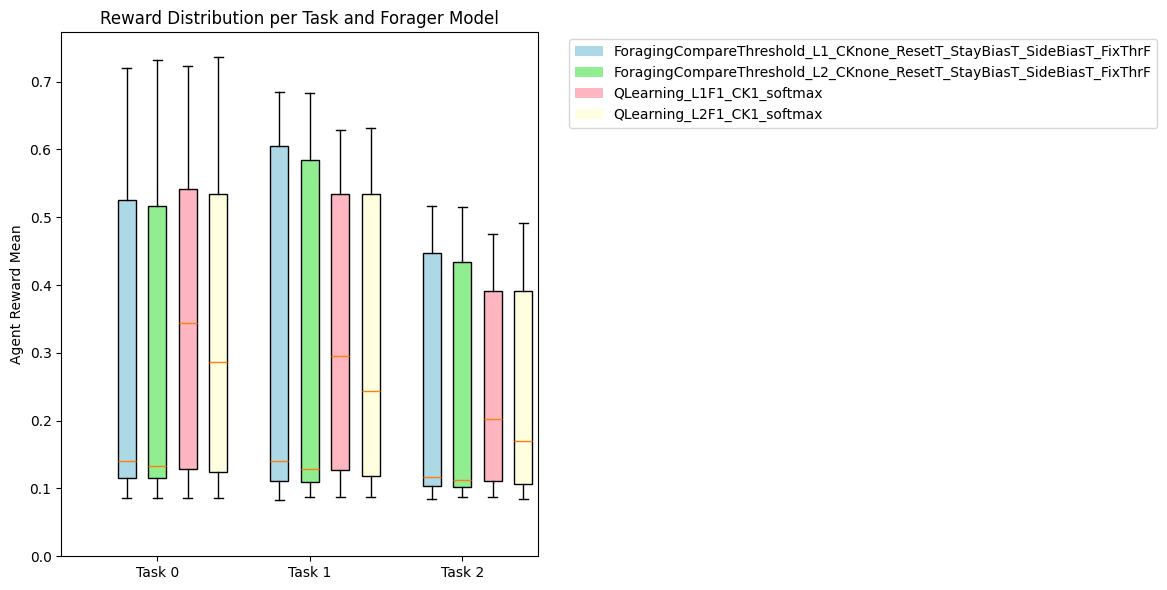

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
csv_path = "/root/capsule/scratch/task_performance_comparison6/all_task_performance_summary.csv"
df = pd.read_csv(csv_path)

# Ensure key columns exist
required_cols = ["task_combo_id", "forager_alias", "agent_reward_mean"]
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"CSV is missing column: {col}")

# Unique tasks and forager aliases
tasks = sorted(df["task_combo_id"].unique())
foragers = sorted(df["forager_alias"].unique())

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

# For each forager, collect rewards for all tasks
data_to_plot = []
positions = []
pos = 1  # x-axis position
width = 0.2  # width between foragers

for t_idx, task in enumerate(tasks):
    for f_idx, forager in enumerate(foragers):
        rewards = df.loc[(df["task_combo_id"] == task) & (df["forager_alias"] == forager), "agent_reward_mean"].values
        if len(rewards) > 0:
            data_to_plot.append(rewards)
            positions.append(pos)
        pos += 1
    # Add extra space between tasks
    pos += 1

# Draw boxplots
bp = ax.boxplot(data_to_plot, positions=positions, widths=0.6, patch_artist=True, showfliers=True)

# Coloring each forager consistently
colors = ["lightblue", "lightgreen", "lightpink", "lightyellow"]
for patch, i in zip(bp['boxes'], range(len(bp['boxes']))):
    patch.set_facecolor(colors[i % len(foragers)])

# X-axis labels
tick_pos = [((i*len(foragers)) + len(foragers)//2 + i) for i in range(len(tasks))]
ax.set_xticks(tick_pos)
ax.set_xticklabels([f"Task {t}" for t in tasks])

ax.set_ylabel("Agent Reward Mean")
ax.set_title("Reward Distribution per Task and Forager Model")

# Add legend manually
for idx, forager in enumerate(foragers):
    ax.bar(0, 0, color=colors[idx], label=forager)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

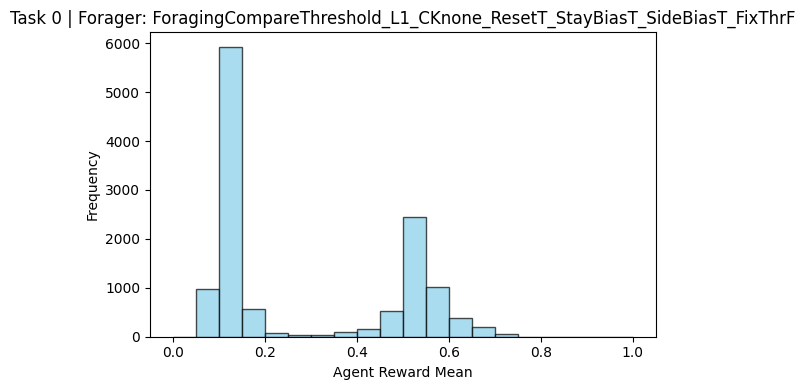

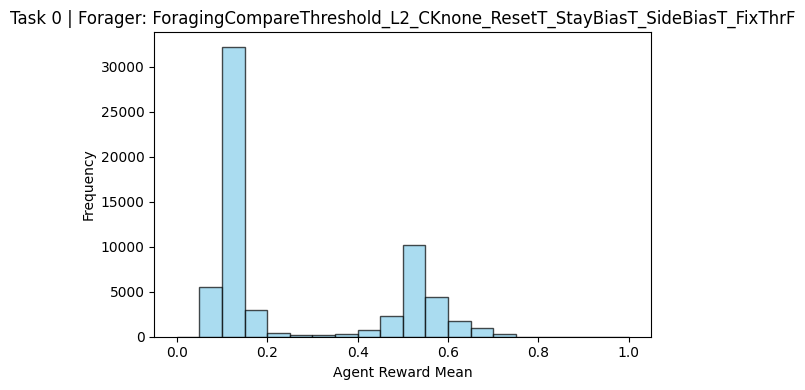

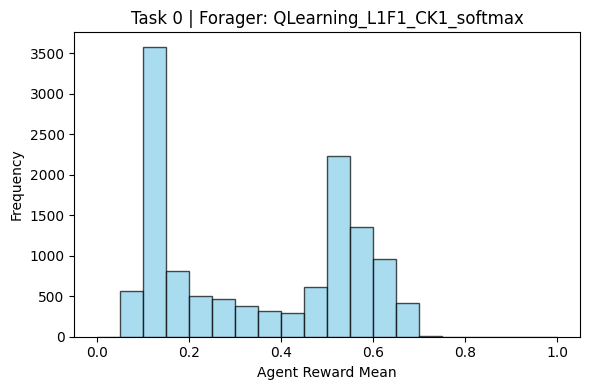

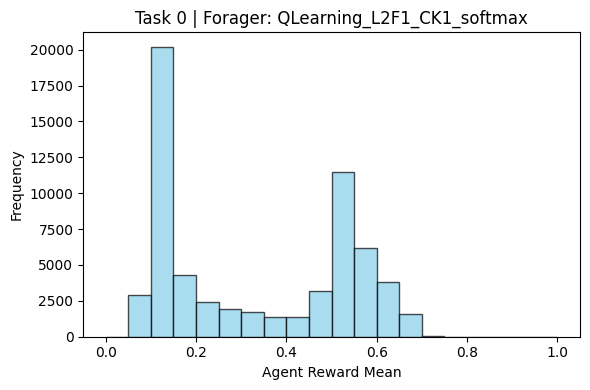

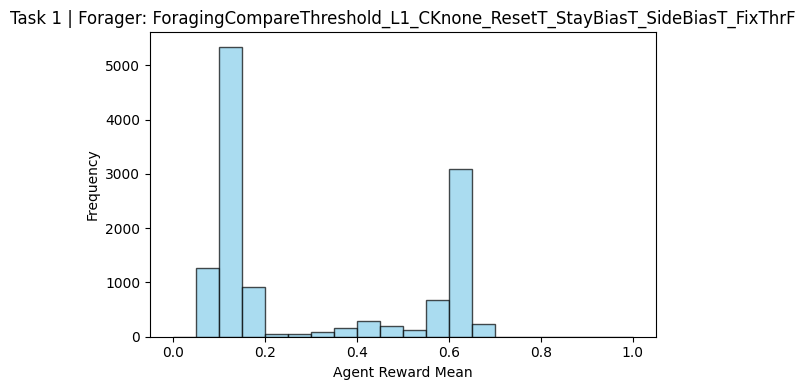

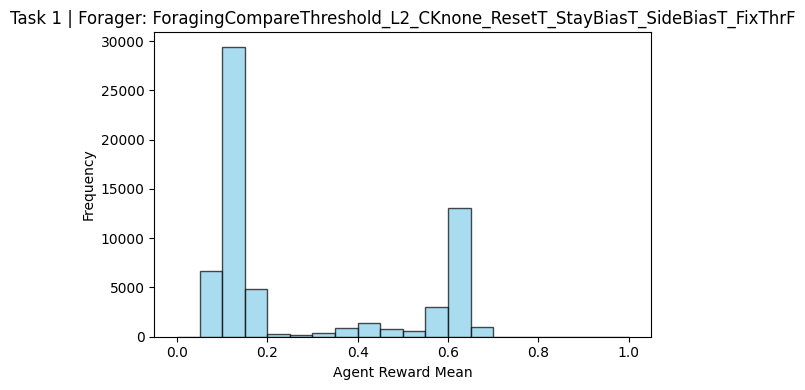

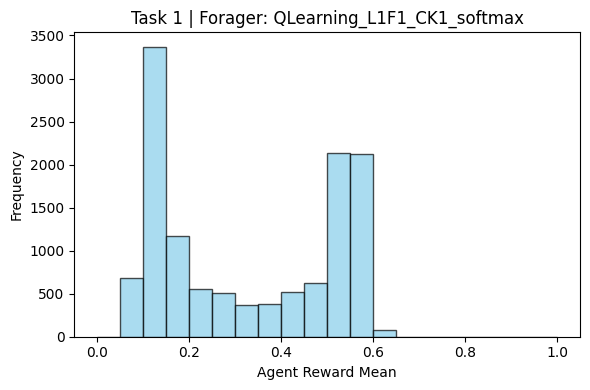

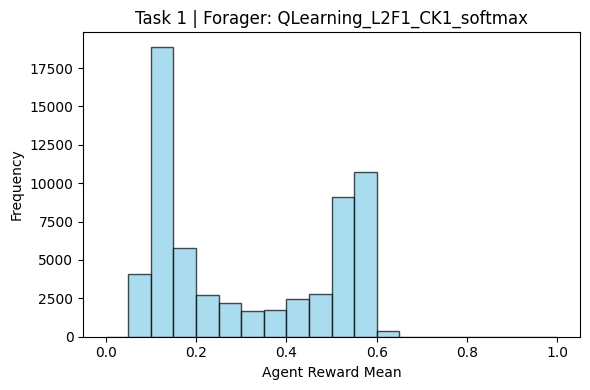

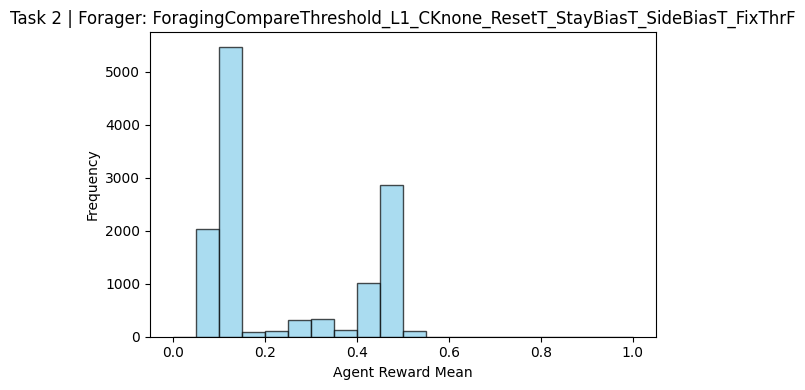

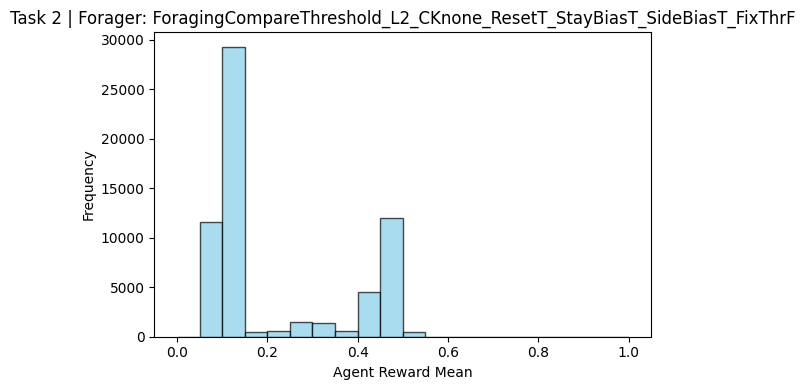

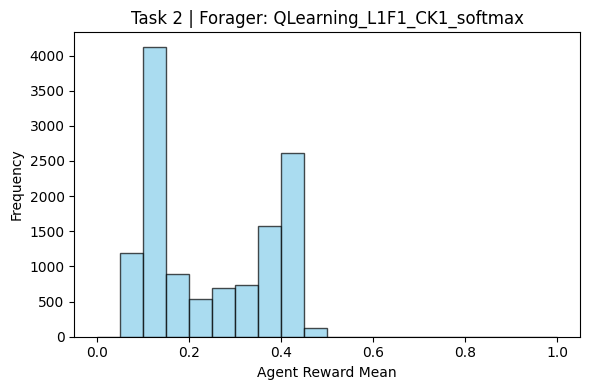

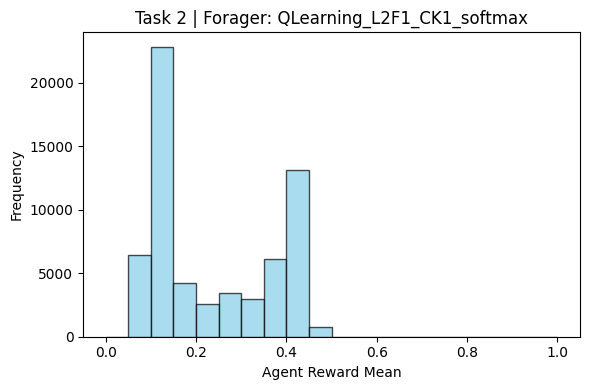

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# Load CSV
csv_path = "/root/capsule/scratch/task_performance_comparison6/all_task_performance_summary.csv"
df = pd.read_csv(csv_path)

# Ensure required columns exist
required_cols = ["task_combo_id", "forager_alias", "agent_reward_mean"]
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"CSV is missing column: {col}")

# Bins for reward rate histogram
bins = np.arange(0, 1.05, 0.05)

# Loop over each task x forager combination and show figure
for task in sorted(df["task_combo_id"].unique()):
    for forager in sorted(df["forager_alias"].unique()):
        rewards = df.loc[
            (df["task_combo_id"] == task) & (df["forager_alias"] == forager),
            "agent_reward_mean"
        ].values
        if len(rewards) == 0:
            continue  # skip if no data

        plt.figure(figsize=(6, 4))
        plt.hist(rewards, bins=bins, color="skyblue", edgecolor="black", alpha=0.7)
        plt.title(f"Task {task} | Forager: {forager}")
        plt.xlabel("Agent Reward Mean")
        plt.ylabel("Frequency")
        plt.tight_layout()

        # Show the figure inline
        plt.show()

In [19]:
import pandas as pd

# Load CSV
csv_path = "/root/capsule/scratch/task_performance_comparison6/all_task_performance_summary.csv"
df = pd.read_csv(csv_path)

# Ensure key columns exist
required_cols = ["task_combo_id", "forager_alias", "repeat_idx", "agent_reward_mean", "forager_param_combo_id"]
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"CSV is missing column: {col}")

# Dictionary to store sorted DataFrames per combination
sorted_dfs = {}

# Loop over each task and forager
for task in sorted(df["task_combo_id"].unique()):
    for forager in sorted(df["forager_alias"].unique()):
        subset = df[(df["task_combo_id"] == task) & (df["forager_alias"] == forager)]
        if len(subset) == 0:
            continue
        # Sort by agent_reward_mean descending
        subset_sorted = subset.sort_values(by="agent_reward_mean", ascending=False).reset_index(drop=True)
        # Save to dict
        sorted_dfs[(task, forager)] = subset_sorted

# Example: show sorted DataFrame for task 0 and first forager
task0_forager0 = sorted_dfs.get((0, sorted(df["forager_alias"].unique())[0]))
task0_forager0

,status,kind,protocol,task_combo_id,task_params,forager_alias,forager_param_combo_id,repeat_idx,num_trials,agent_reward_mean,agent_reward_sum,forager_params
0,ok,task_performance,Uncoupled NoBaiting,0,"{'rwd_prob_array': [0.1, 0.5, 0.9], 'block_min...",ForagingCompareThreshold_L1_CKnone_ResetT_Stay...,494,10,1000,0.720,720.0,"{'learn_rate': 0.7525, 'threshold': 0.8, 'soft..."
1,ok,task_performance,Uncoupled NoBaiting,0,"{'rwd_prob_array': [0.1, 0.5, 0.9], 'block_min...",ForagingCompareThreshold_L1_CKnone_ResetT_Stay...,363,10,1000,0.720,720.0,"{'learn_rate': 0.505, 'threshold': 0.8, 'softm..."
2,ok,task_performance,Uncoupled NoBaiting,0,"{'rwd_prob_array': [0.1, 0.5, 0.9], 'block_min...",ForagingCompareThreshold_L1_CKnone_ResetT_Stay...,368,10,1000,0.719,719.0,"{'learn_rate': 0.505, 'threshold': 0.8, 'softm..."
3,ok,task_performance,Uncoupled NoBaiting,0,"{'rwd_prob_array': [0.1, 0.5, 0.9], 'block_min...",ForagingCompareThreshold_L1_CKnone_ResetT_Stay...,364,11,1000,0.719,719.0,"{'learn_rate': 0.505, 'threshold': 0.8, 'softm..."
4,ok,task_performance,Uncoupled NoBaiting,0,"{'rwd_prob_array': [0.1, 0.5, 0.9], 'block_min...",ForagingCompareThreshold_L1_CKnone_ResetT_Stay...,623,10,1000,0.718,718.0,"{'learn_rate': 1.0, 'threshold': 0.8, 'softmax..."
...,...,...,...,...,...,...,...,...,...,...,...,...
12495,ok,task_performance,Uncoupled NoBaiting,0,"{'rwd_prob_array': [0.1, 0.5, 0.9], 'block_min...",ForagingCompareThreshold_L1_CKnone_ResetT_Stay...,381,3,1000,0.086,86.0,"{'learn_rate': 0.7525, 'threshold': -10.0, 'so..."
12496,ok,task_performance,Uncoupled NoBaiting,0,"{'rwd_prob_array': [0.1, 0.5, 0.9], 'block_min...",ForagingCompareThreshold_L1_CKnone_ResetT_Stay...,392,3,1000,0.086,86.0,"{'learn_rate': 0.7525, 'threshold': -10.0, 'so..."
12497,ok,task_performance,Uncoupled NoBaiting,0,"{'rwd_prob_array': [0.1, 0.5, 0.9], 'block_min...",ForagingCompareThreshold_L1_CKnone_ResetT_Stay...,395,3,1000,0.086,86.0,"{'learn_rate': 0.7525, 'threshold': -10.0, 'so..."
12498,ok,task_performance,Uncoupled NoBaiting,0,"{'rwd_prob_array': [0.1, 0.5, 0.9], 'block_min...",ForagingCompareThreshold_L1_CKnone_ResetT_Stay...,396,3,1000,0.086,86.0,"{'learn_rate': 0.7525, 'threshold': -10.0, 'so..."


In [20]:
import pandas as pd
import ast

# Load CSV
csv_path = "/root/capsule/scratch/task_performance_comparison6/all_task_performance_summary.csv"
df = pd.read_csv(csv_path)

# Ensure key columns exist
required_cols = ["task_combo_id", "forager_alias", "repeat_idx", "agent_reward_mean", "forager_param_combo_id", "forager_params"]
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"CSV is missing column: {col}")

# Convert forager_params string to dict if needed
if df["forager_params"].dtype == object:
    df["forager_params"] = df["forager_params"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else {})

# Loop over each task x forager and print top/bottom 5
for task in sorted(df["task_combo_id"].unique()):
    for forager in sorted(df["forager_alias"].unique()):
        subset = df[(df["task_combo_id"] == task) & (df["forager_alias"] == forager)]
        if len(subset) == 0:
            continue

        # Sort descending by reward
        subset_sorted = subset.sort_values(by="agent_reward_mean", ascending=False).reset_index(drop=True)

        print(f"\n=== Task {task} | Forager {forager} ===\n")
        print("Top 5 best repeats:")
        print(subset_sorted[["repeat_idx", "forager_param_combo_id", "agent_reward_mean", "forager_params"]].head(5).to_string(index=False))

        print("\nBottom 5 worst repeats:")
        print(subset_sorted[["repeat_idx", "forager_param_combo_id", "agent_reward_mean", "forager_params"]].tail(5).to_string(index=False))
        print("-" * 80)


=== Task 0 | Forager ForagingCompareThreshold_L1_CKnone_ResetT_StayBiasT_SideBiasT_FixThrF ===

Top 5 best repeats:
 repeat_idx  forager_param_combo_id  agent_reward_mean                                                                                                            forager_params
         10                     494              0.720 {'learn_rate': 0.7525, 'threshold': 0.8, 'softmax_inverse_temperature': 15.024999999999999, 'stay_bias': 6.0, 'biasL': 0}
         10                     363              0.720  {'learn_rate': 0.505, 'threshold': 0.8, 'softmax_inverse_temperature': 10.049999999999999, 'stay_bias': 2.0, 'biasL': 0}
         10                     368              0.719  {'learn_rate': 0.505, 'threshold': 0.8, 'softmax_inverse_temperature': 15.024999999999999, 'stay_bias': 2.0, 'biasL': 0}
         11                     364              0.719  {'learn_rate': 0.505, 'threshold': 0.8, 'softmax_inverse_temperature': 10.049999999999999, 'stay_bias': 6.0, 'biasL': 0

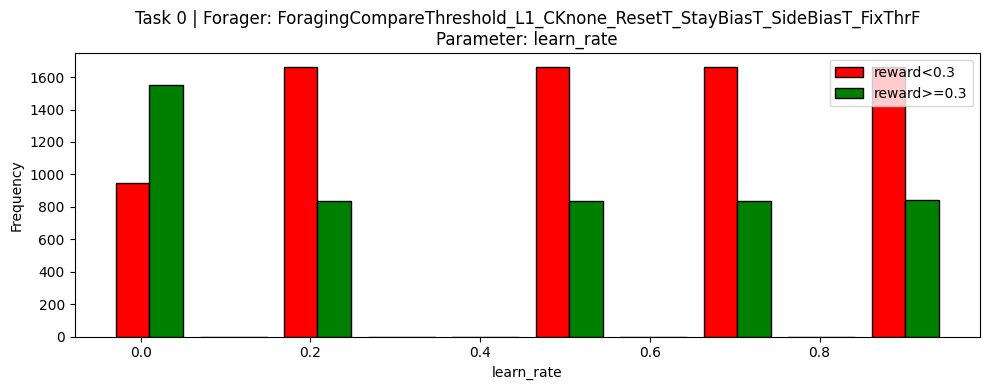

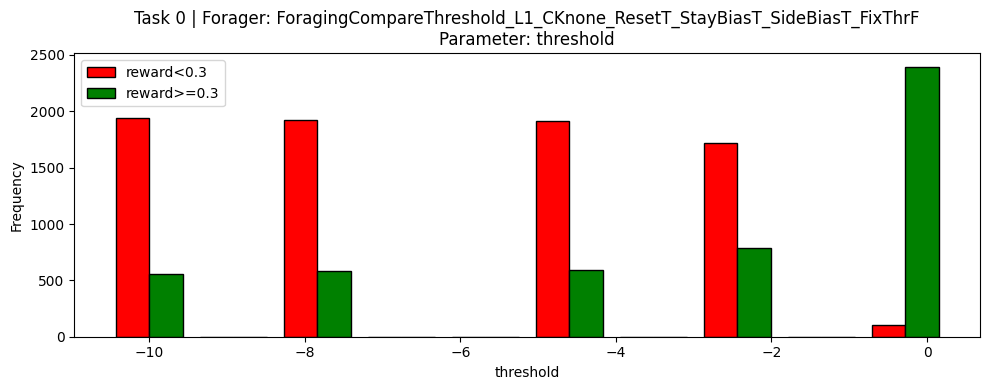

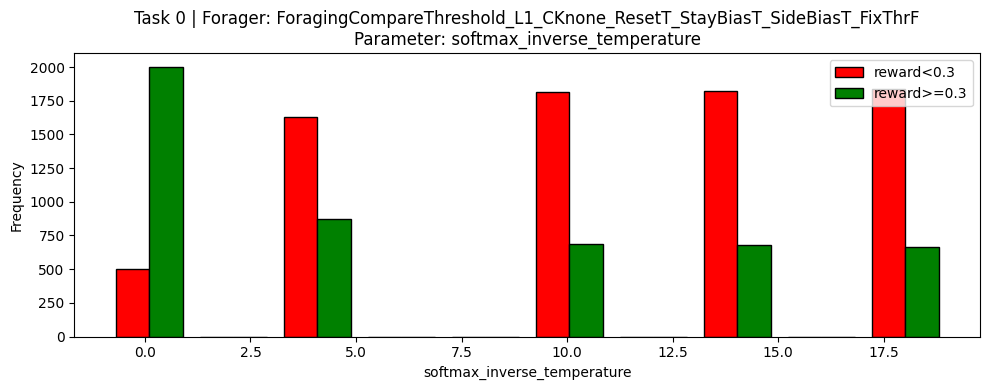

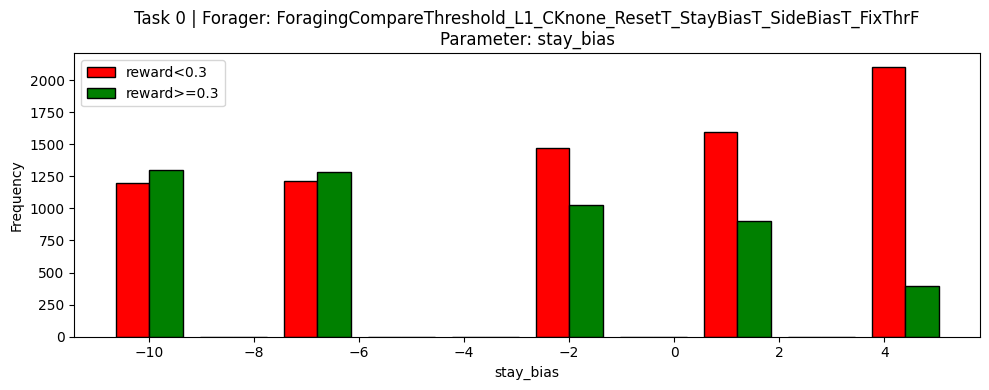

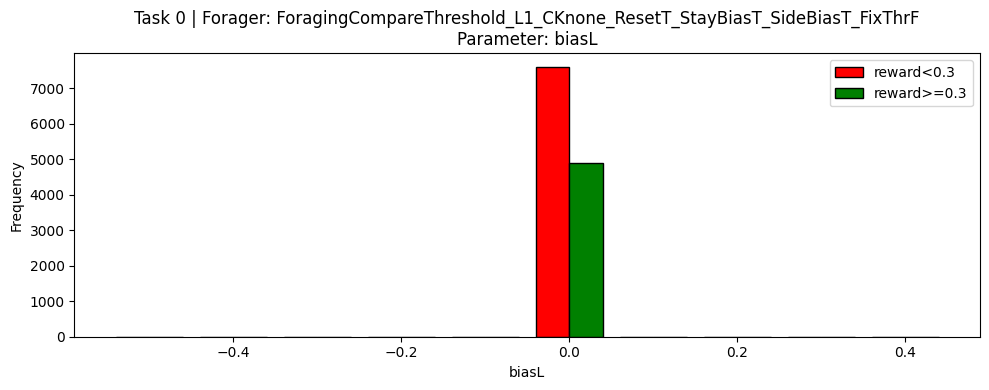

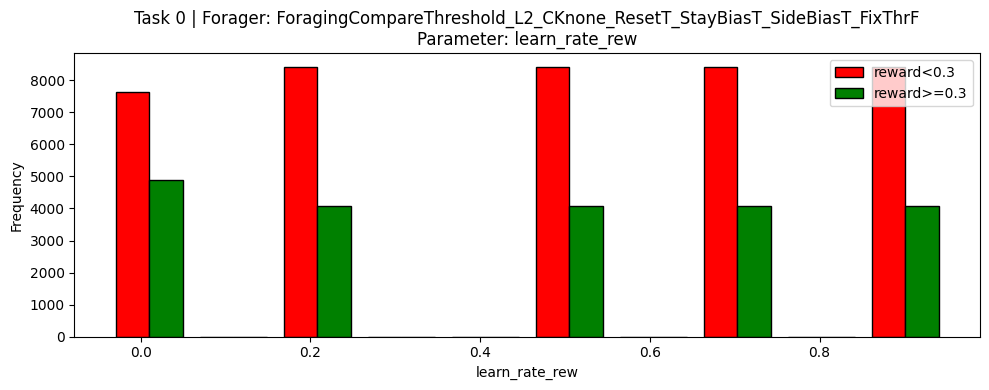

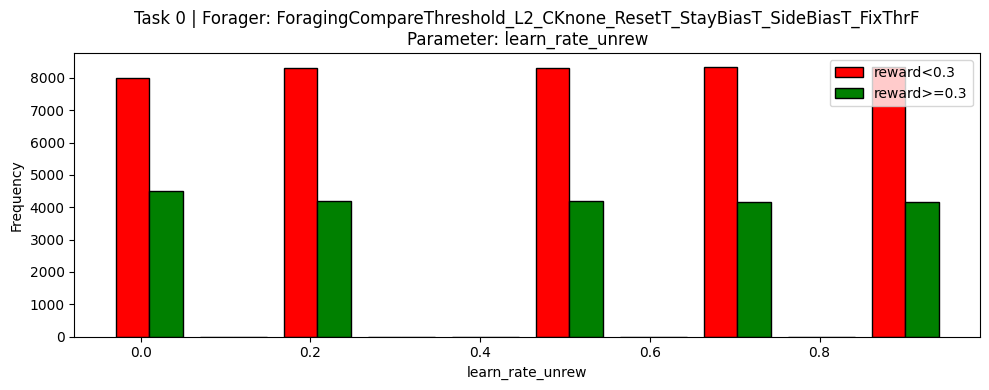

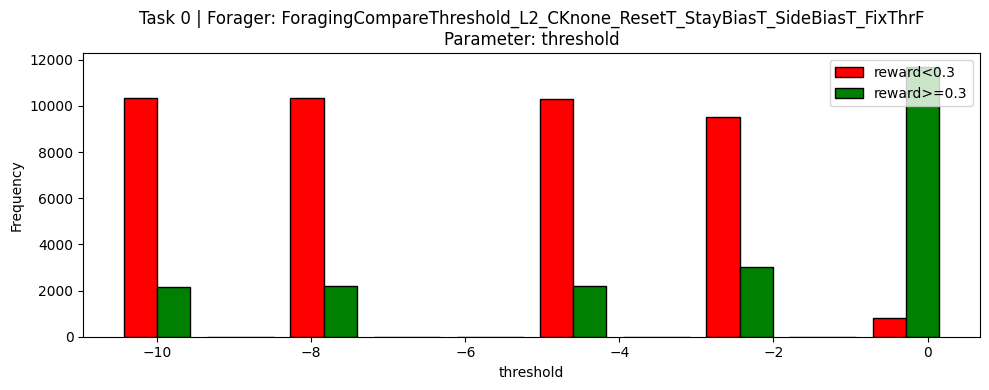

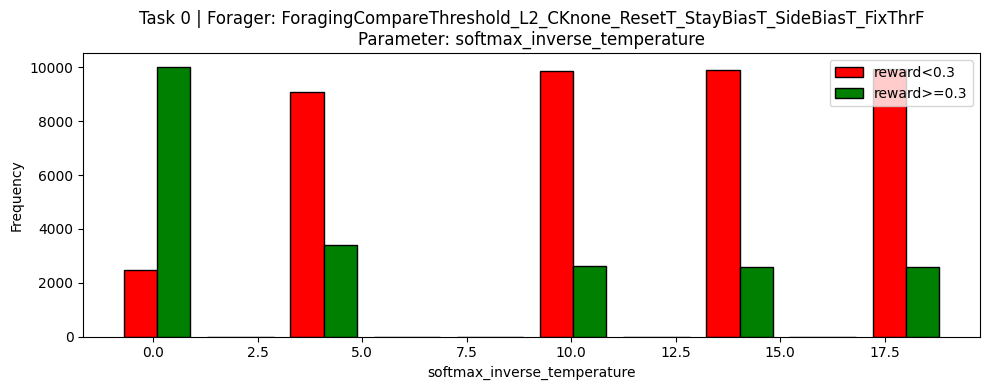

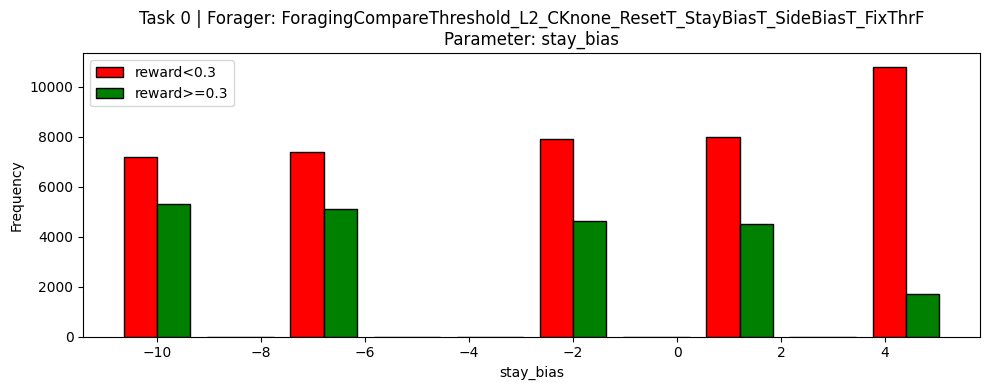

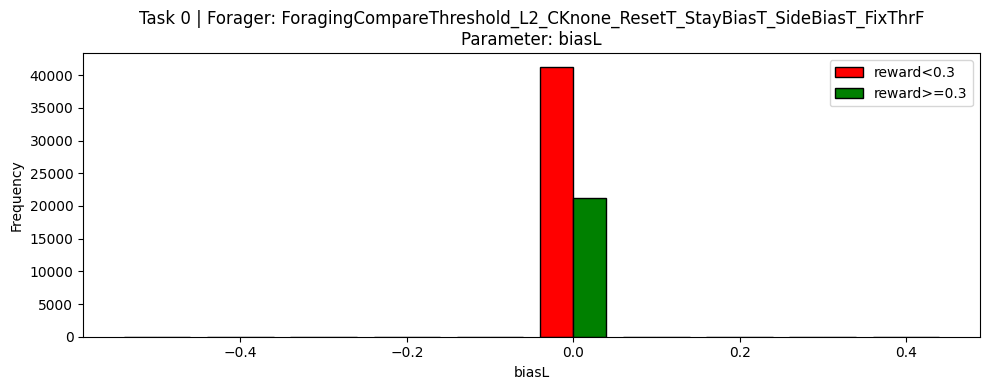

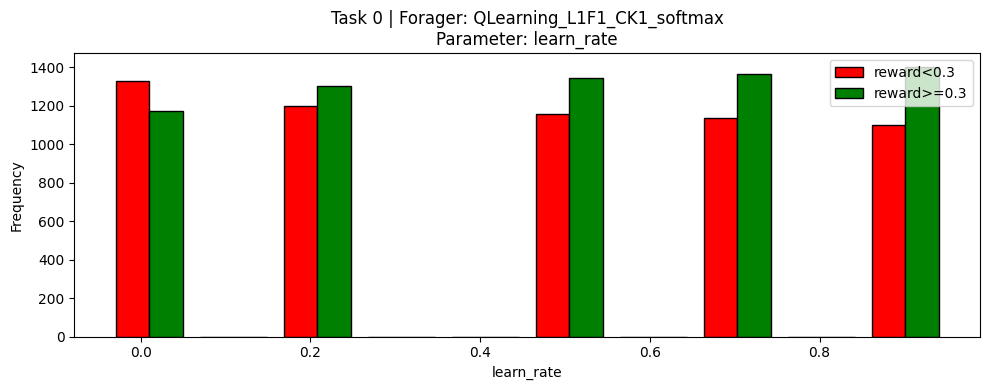

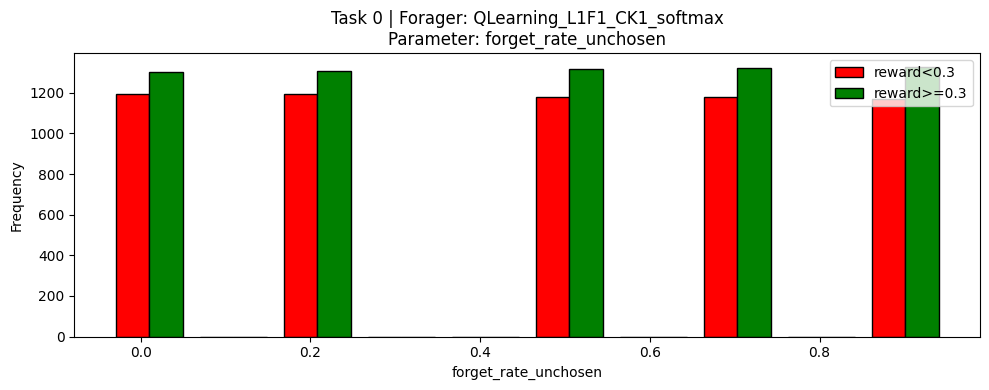

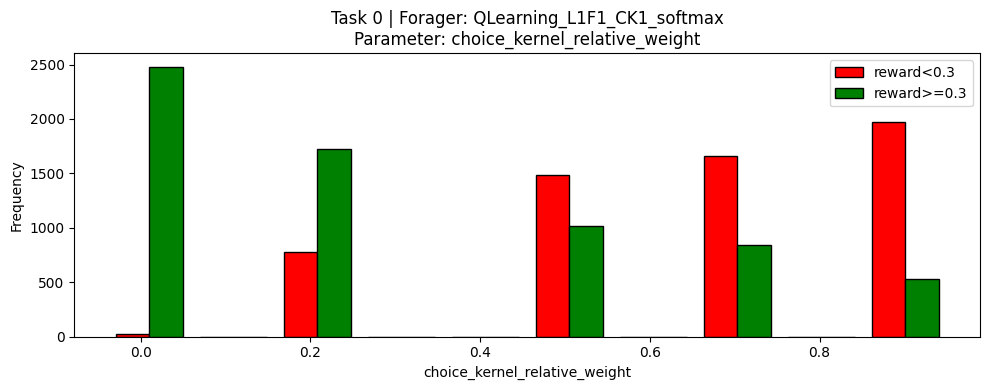

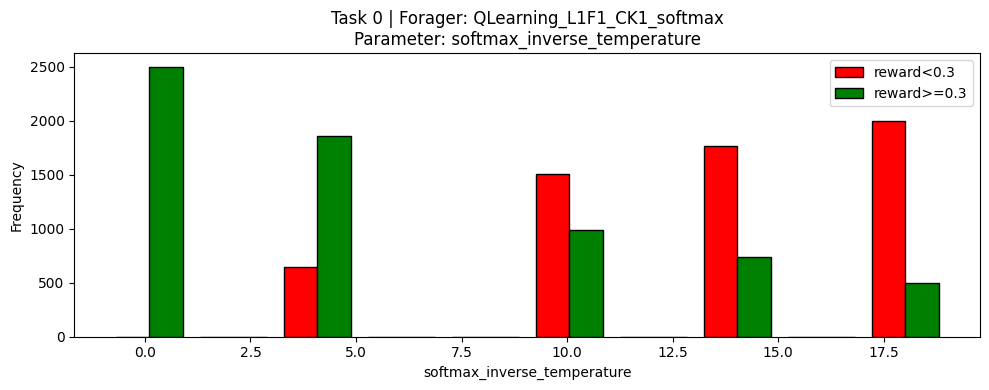

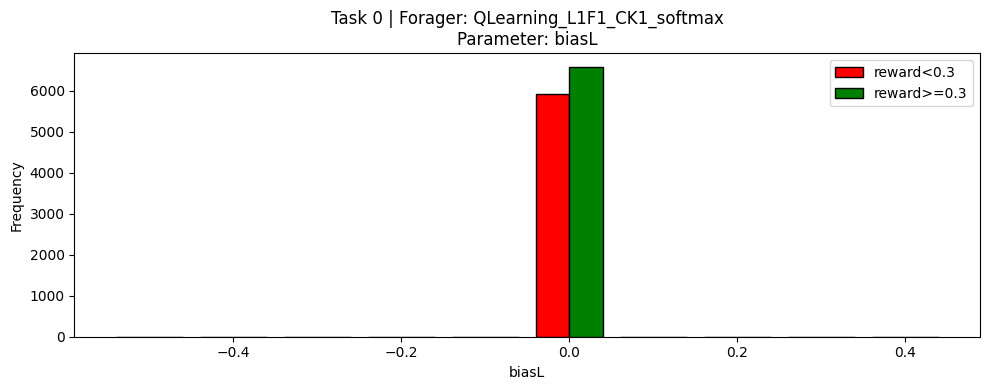

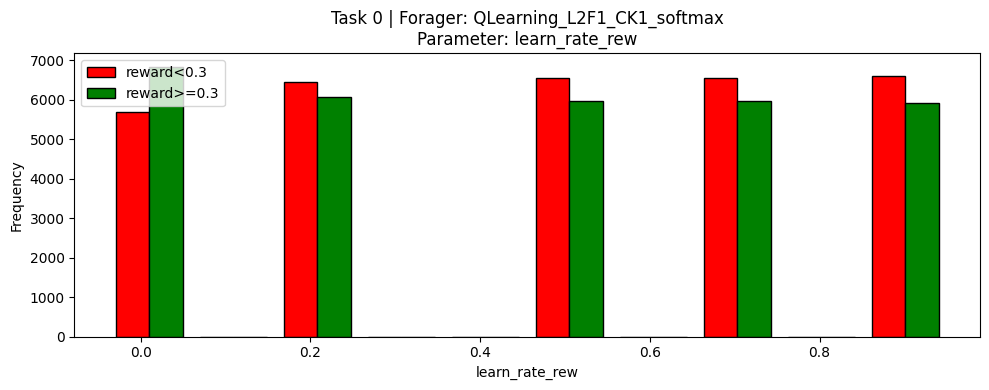

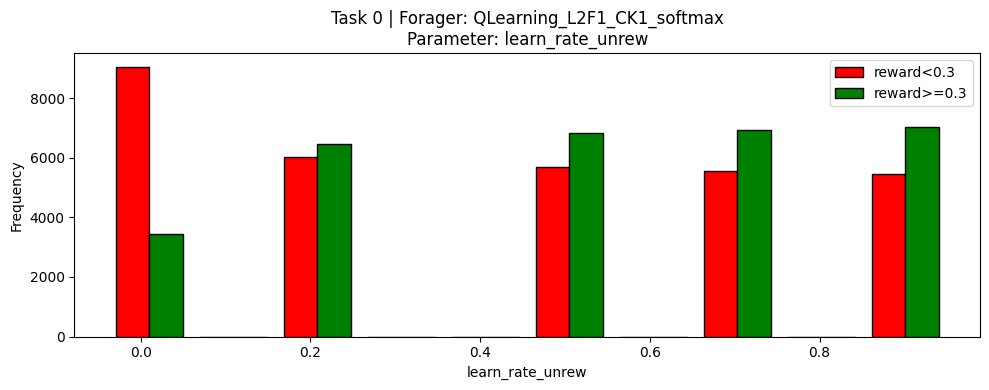

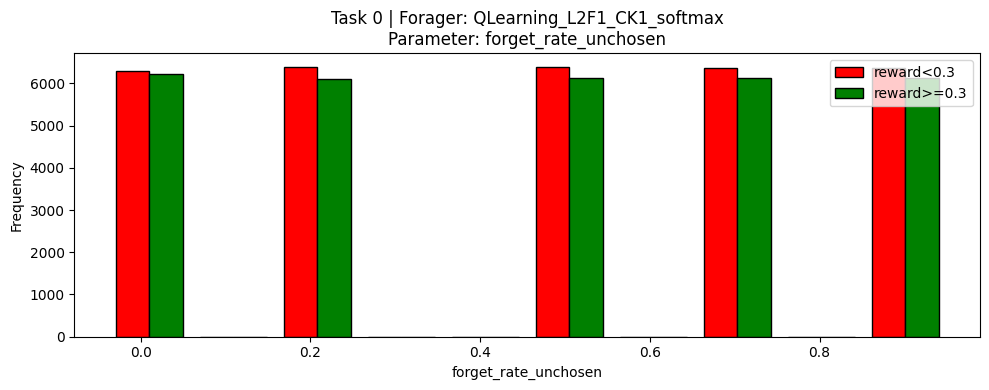

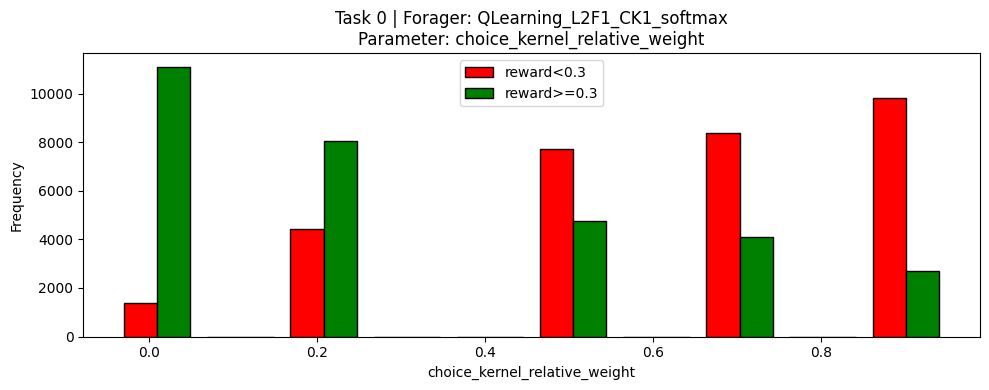

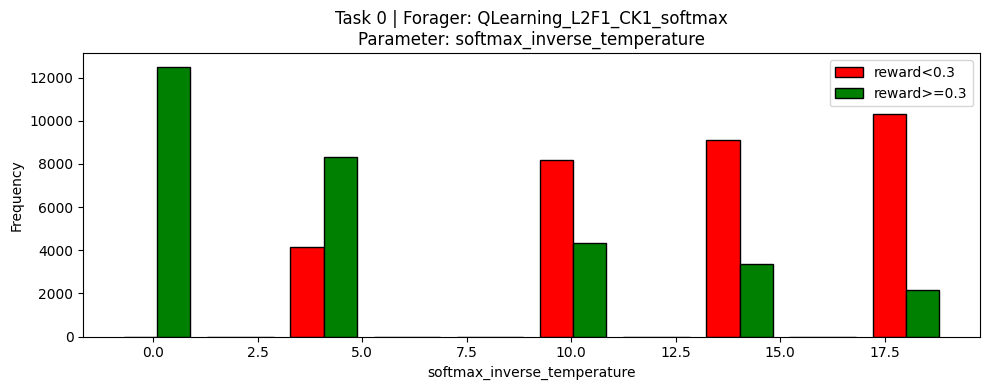

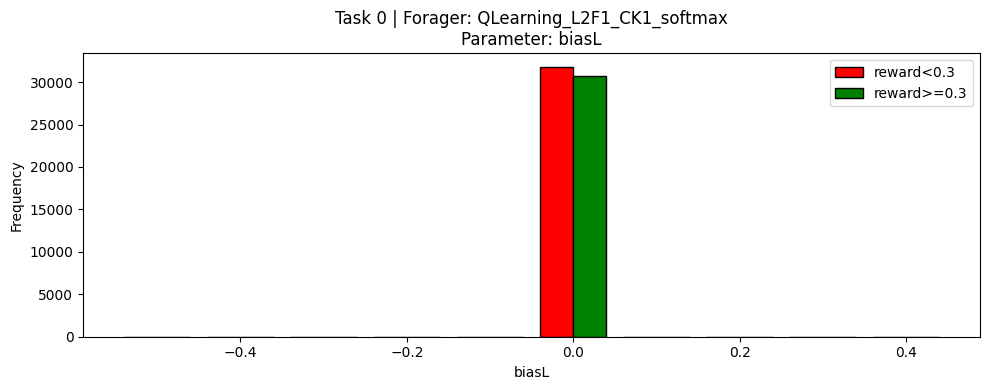

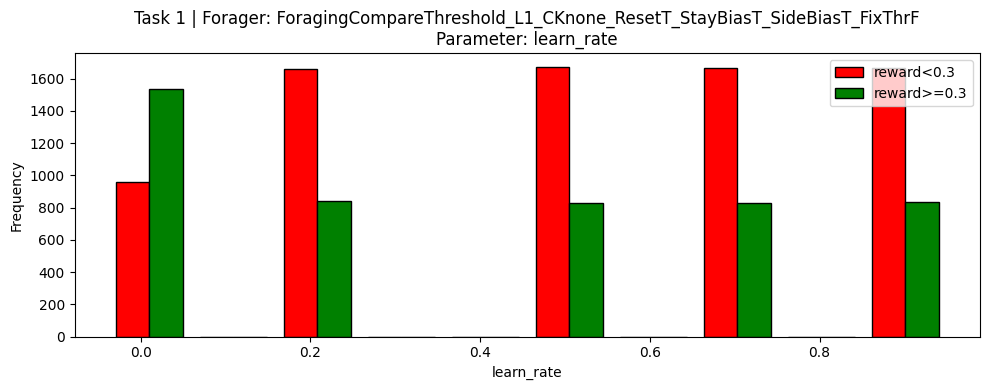

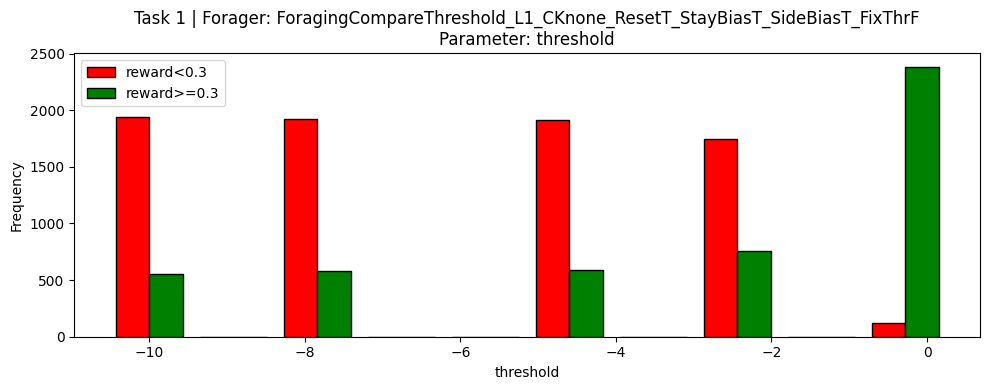

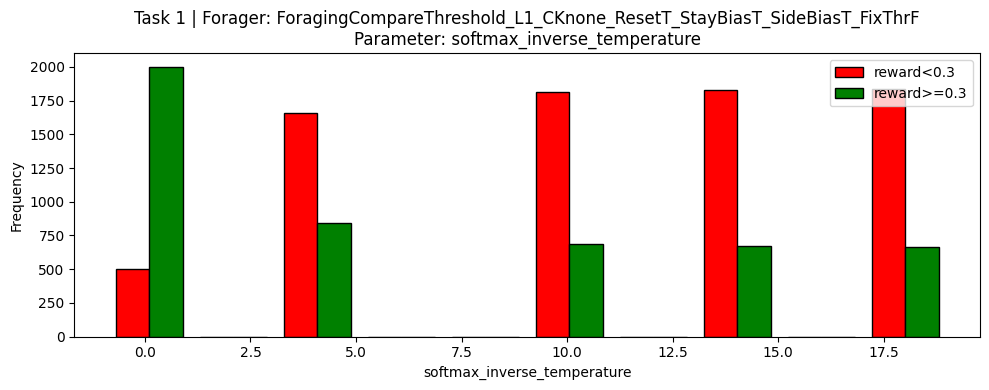

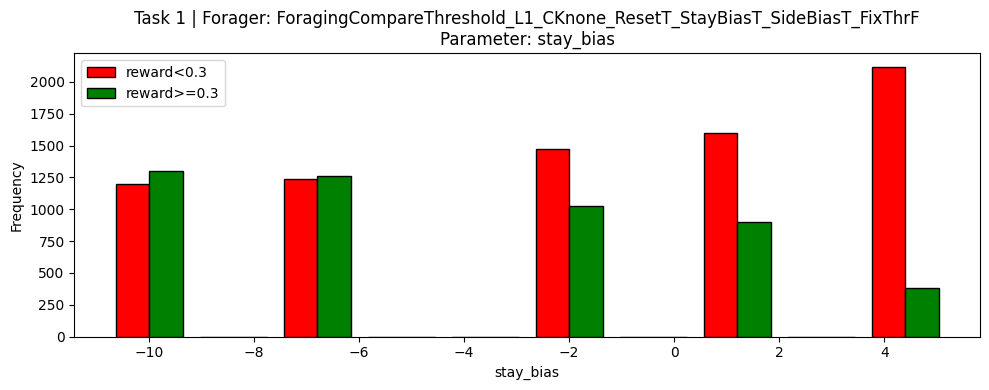

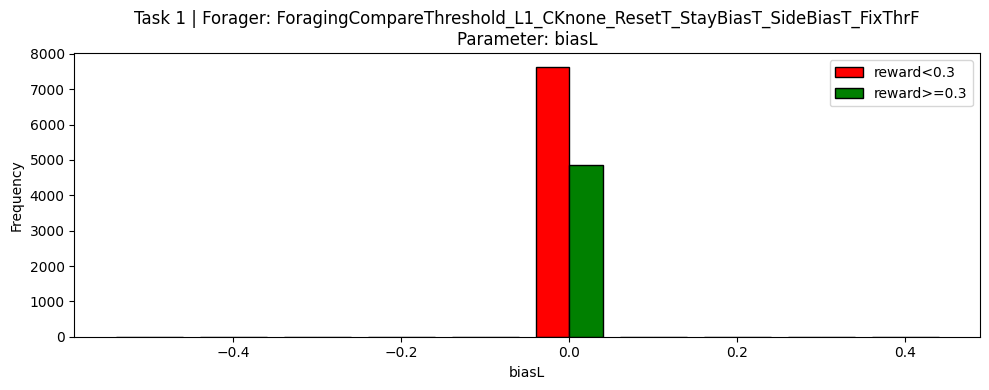

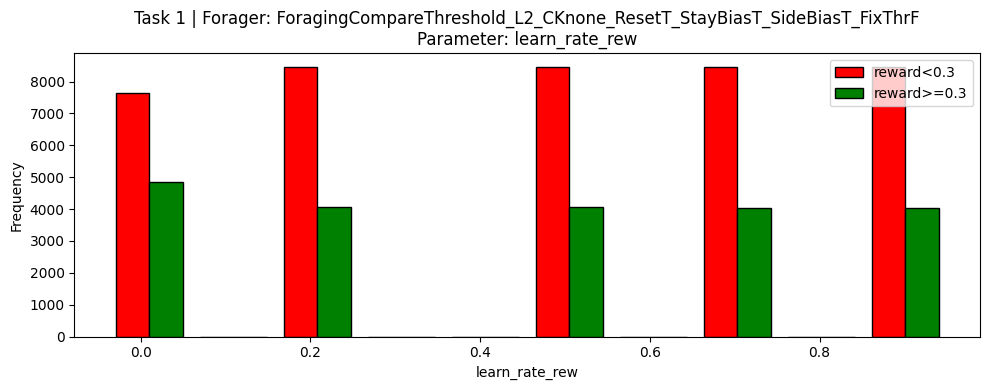

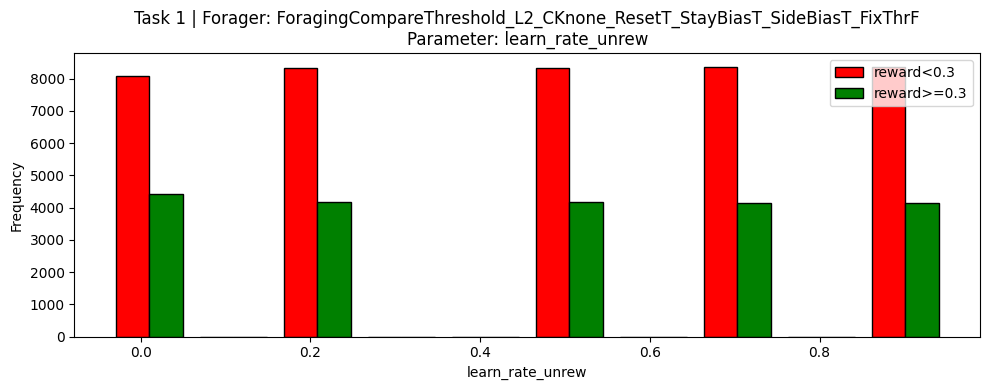

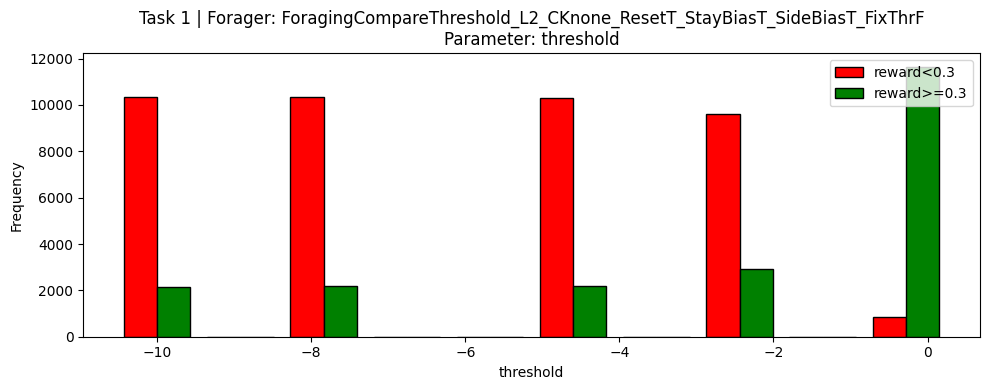

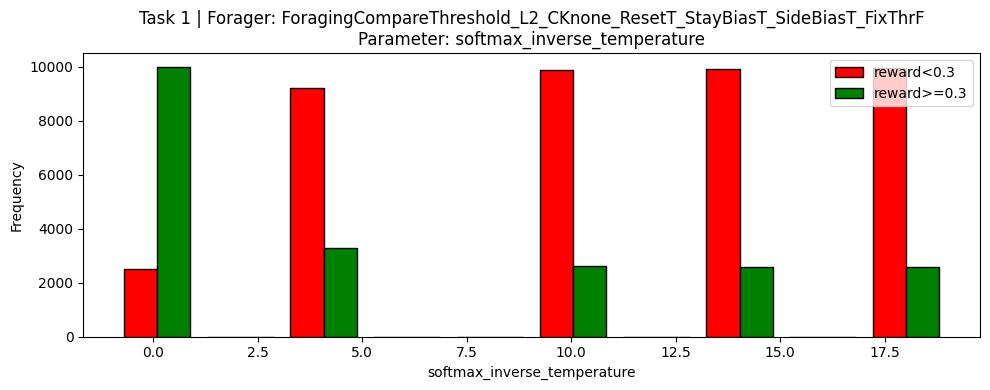

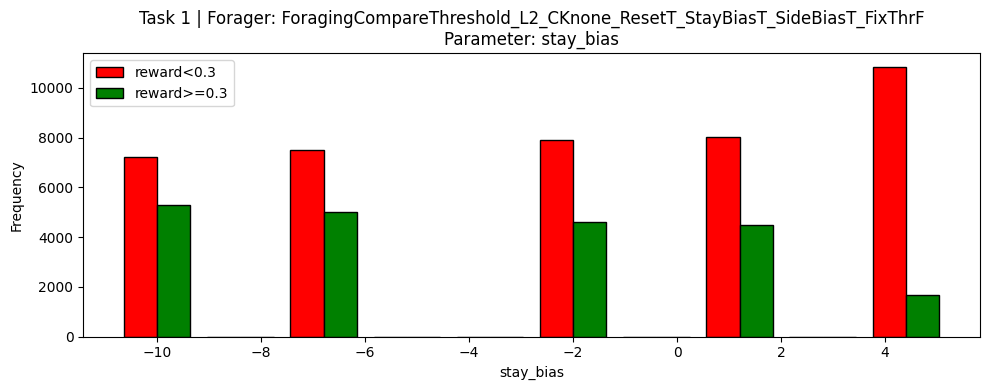

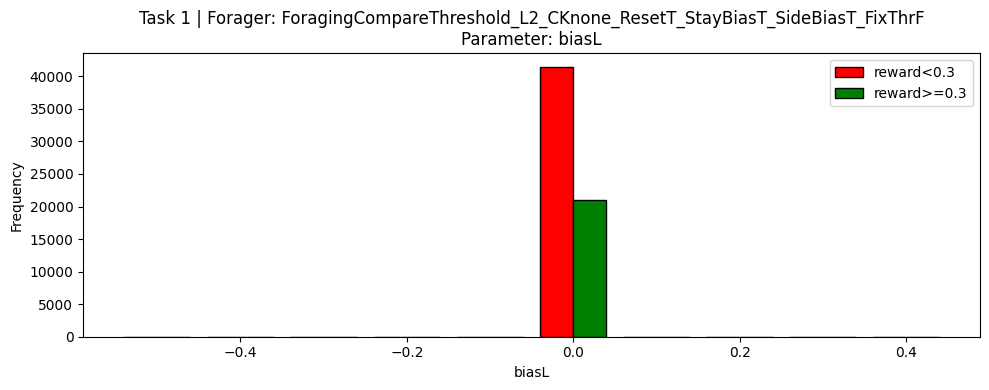

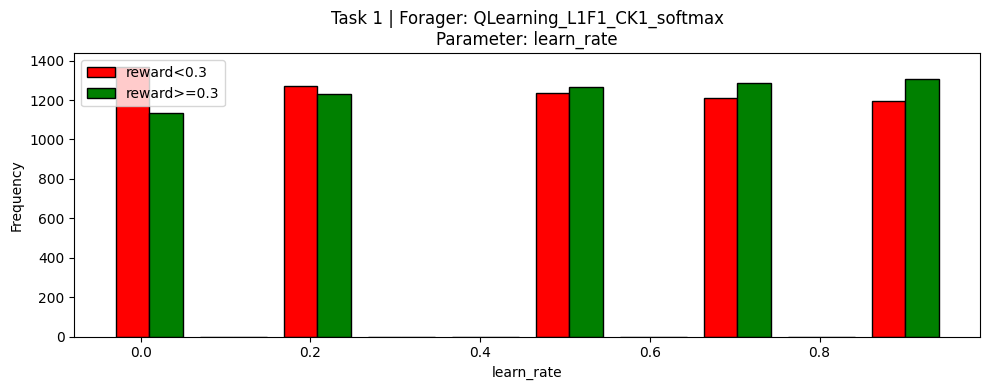

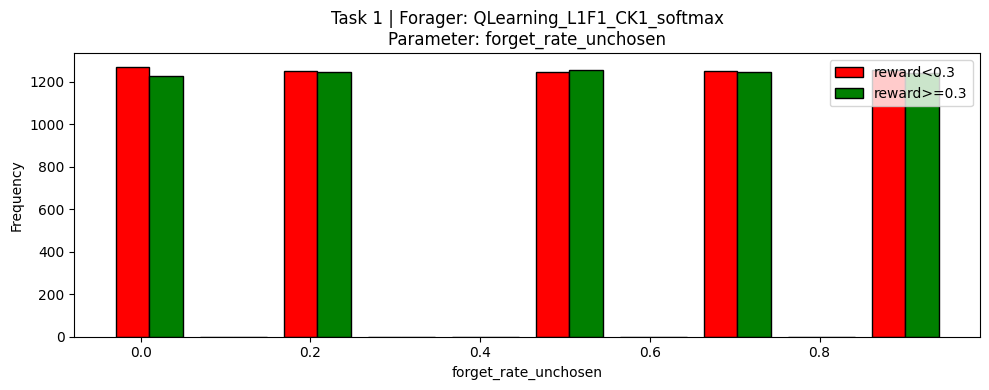

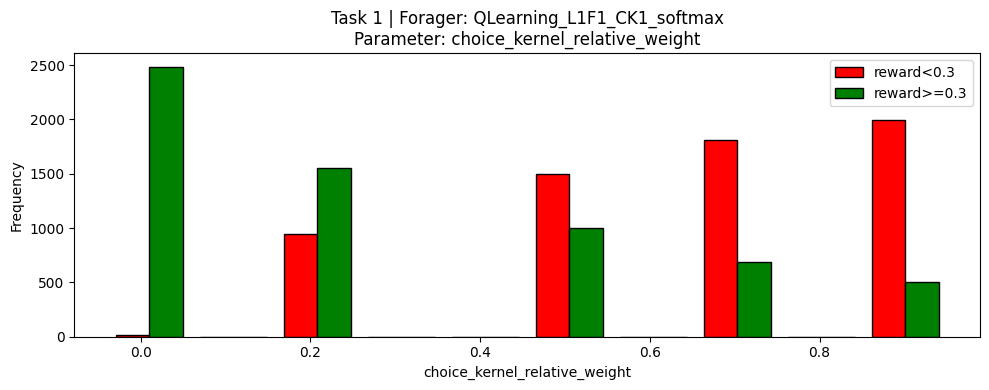

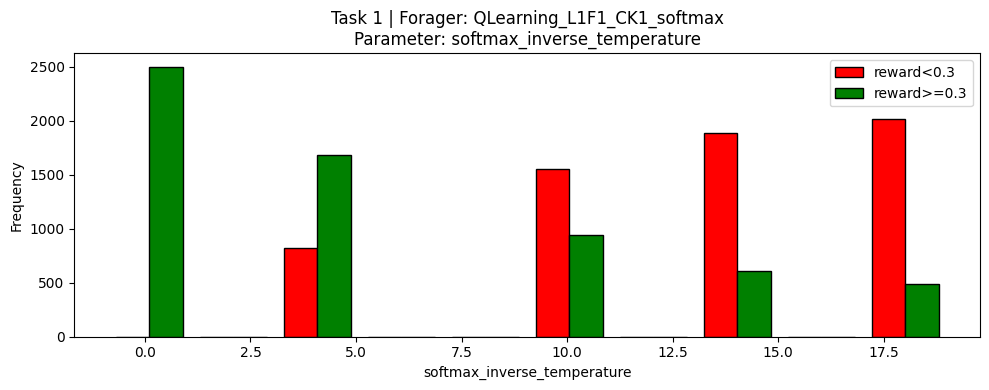

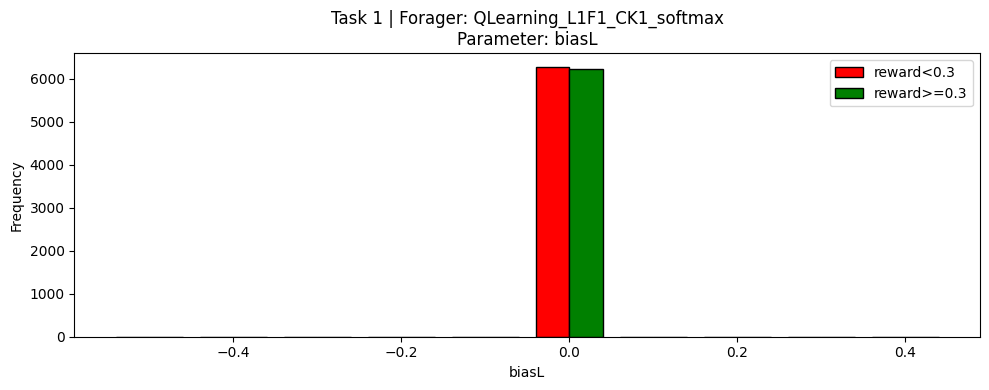

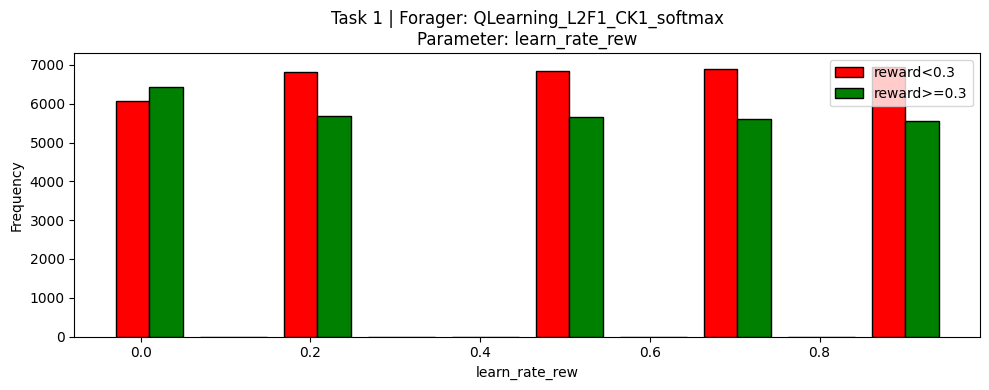

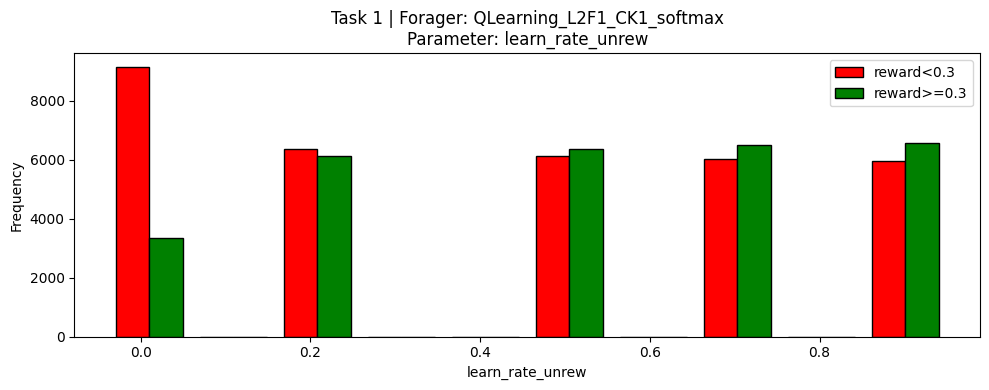

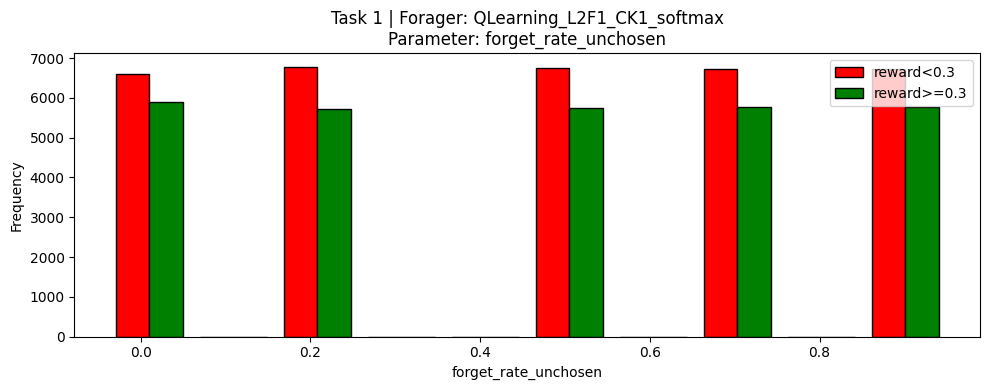

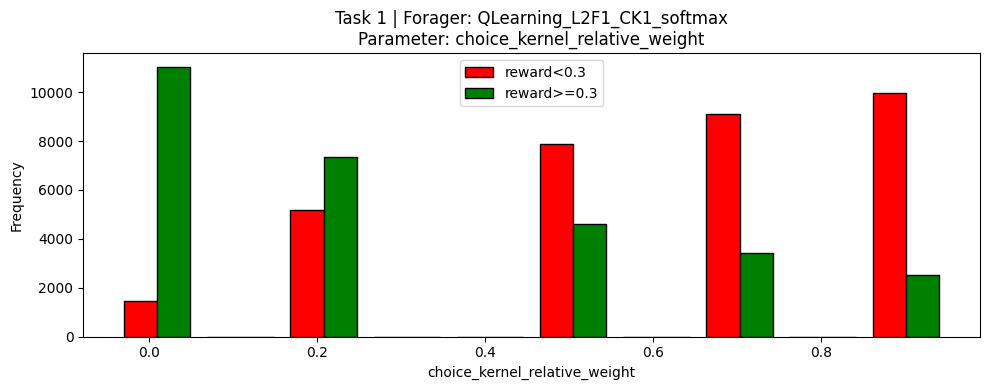

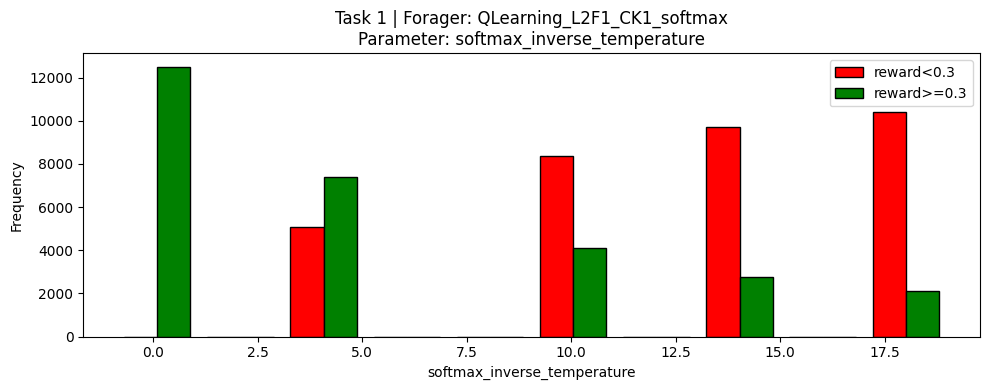

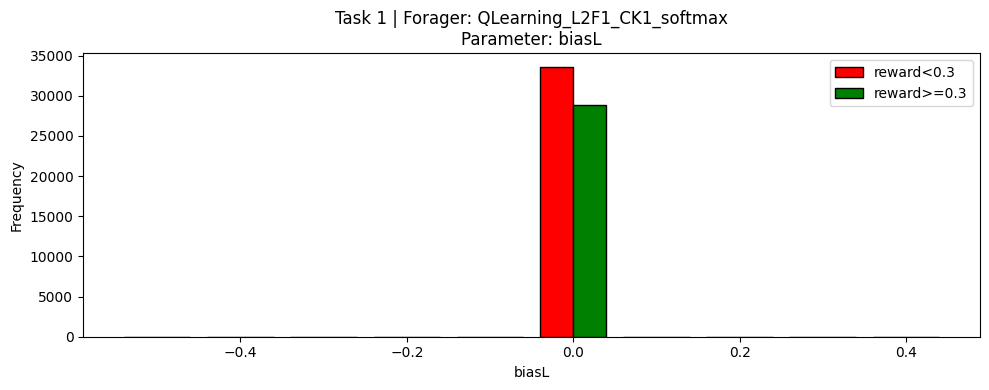

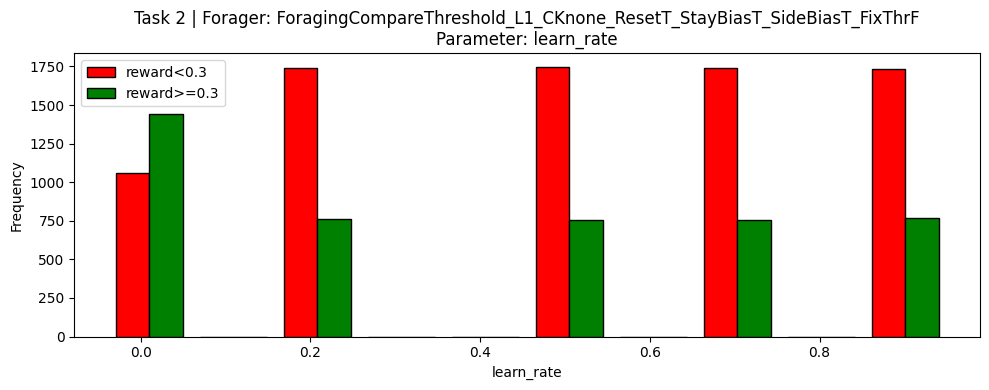

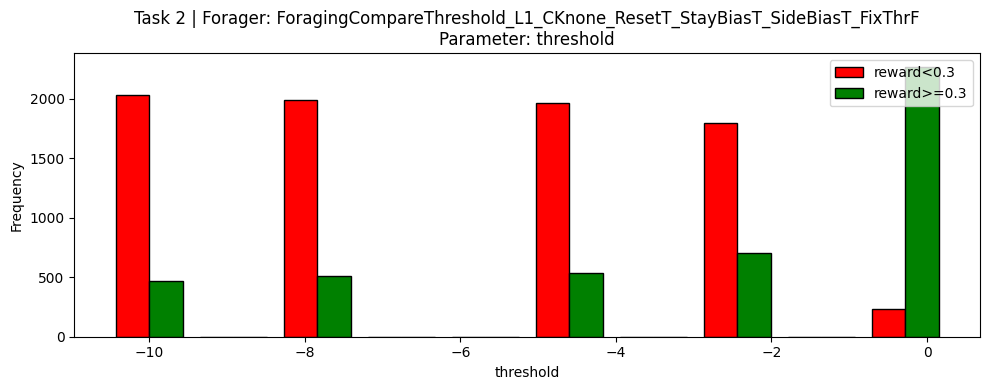

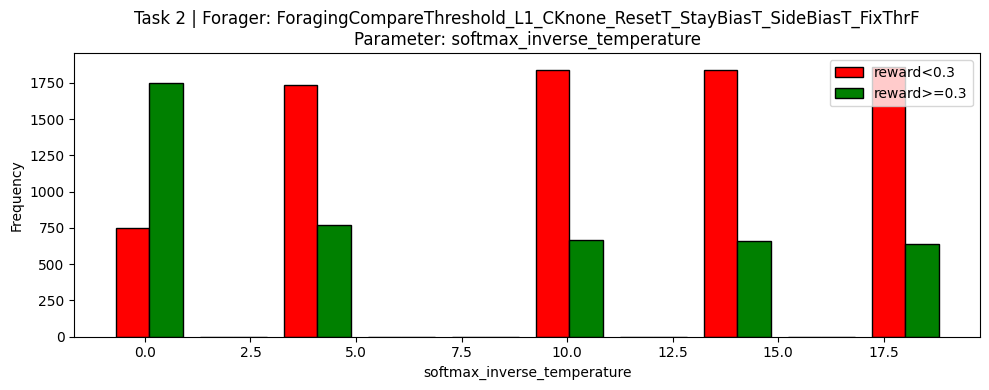

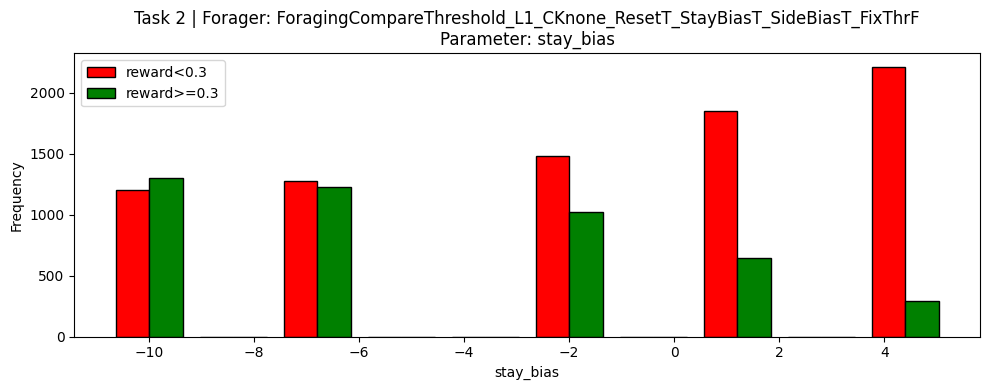

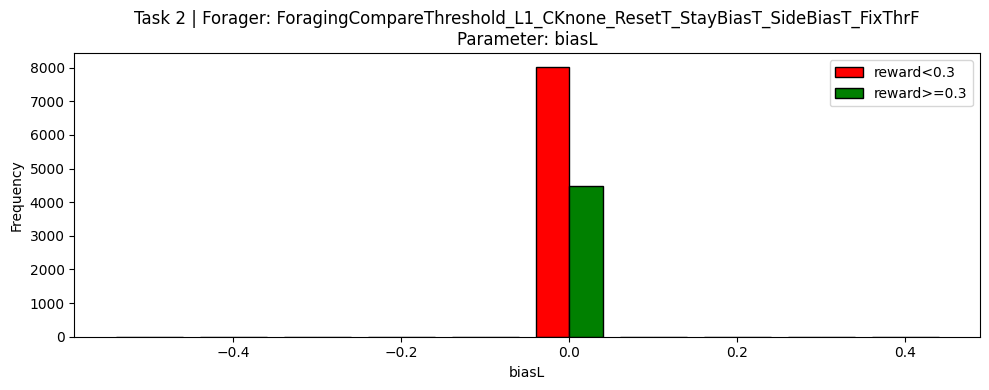

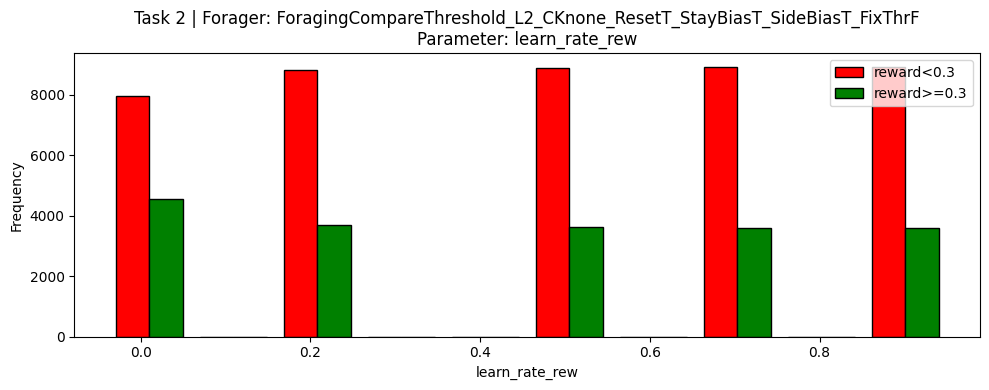

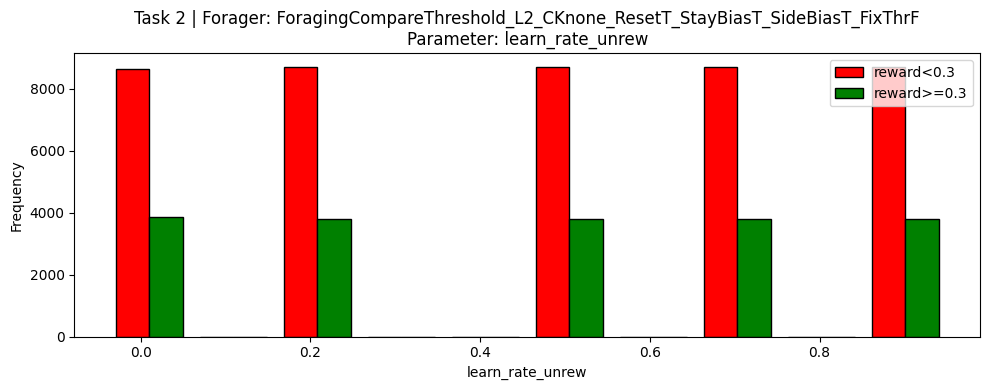

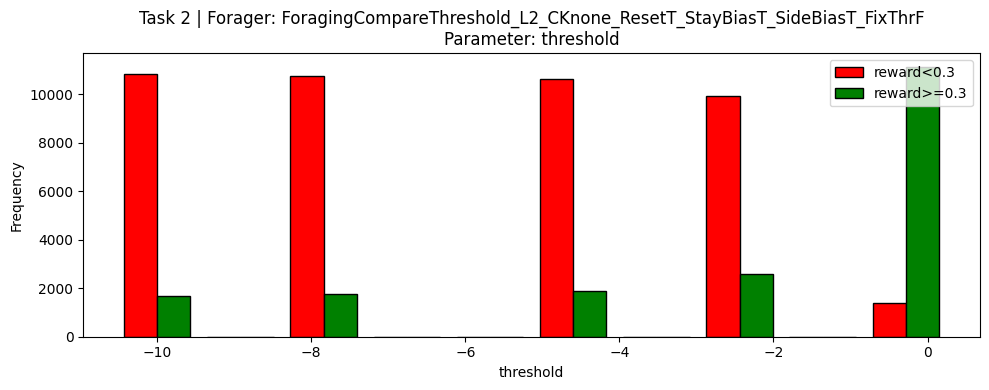

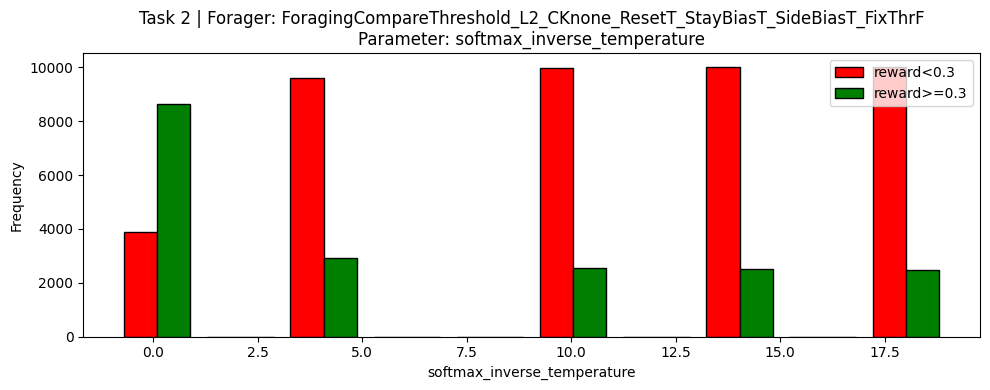

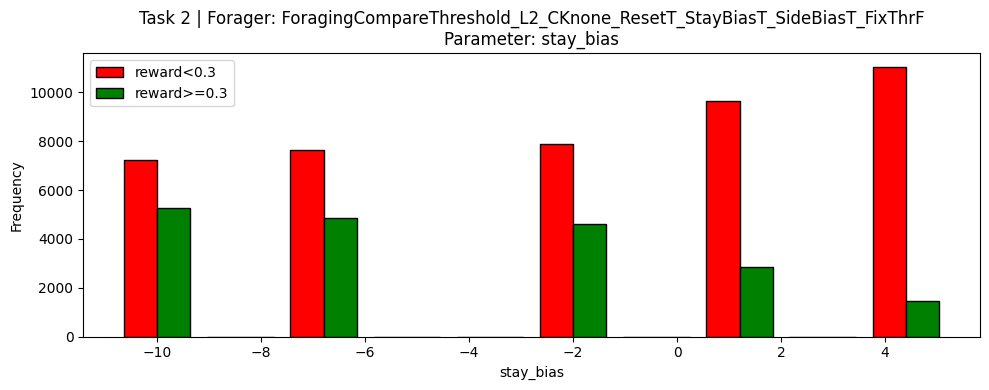

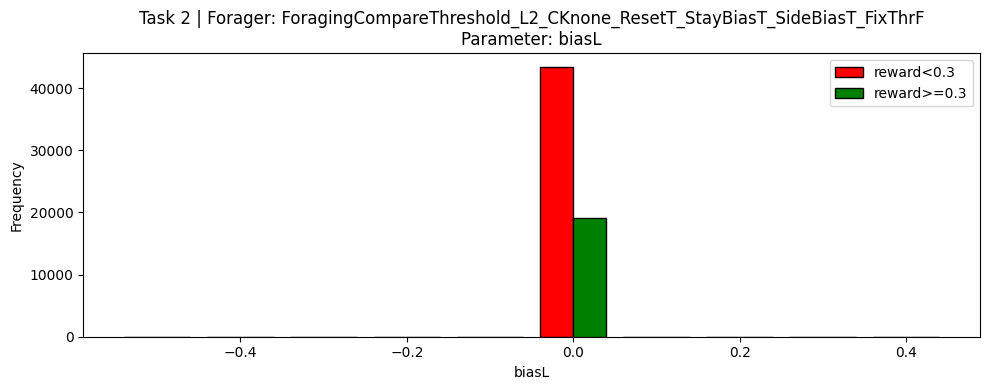

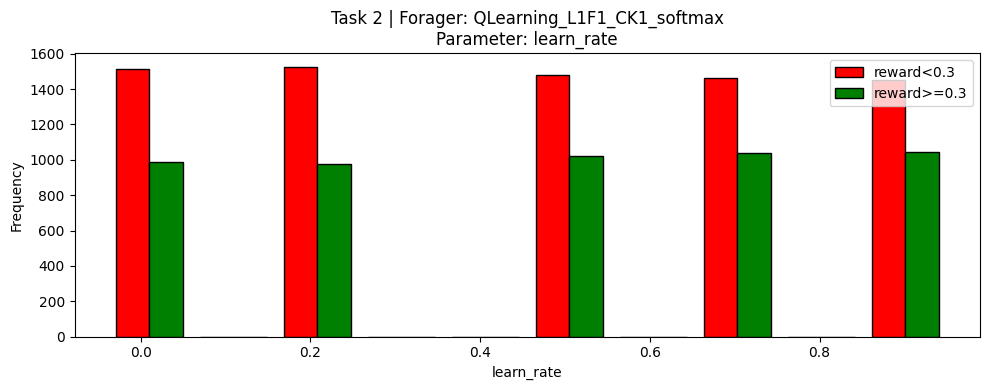

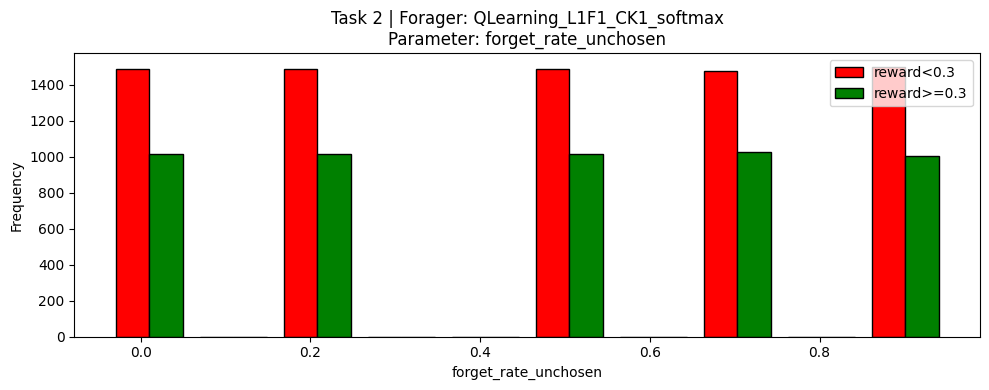

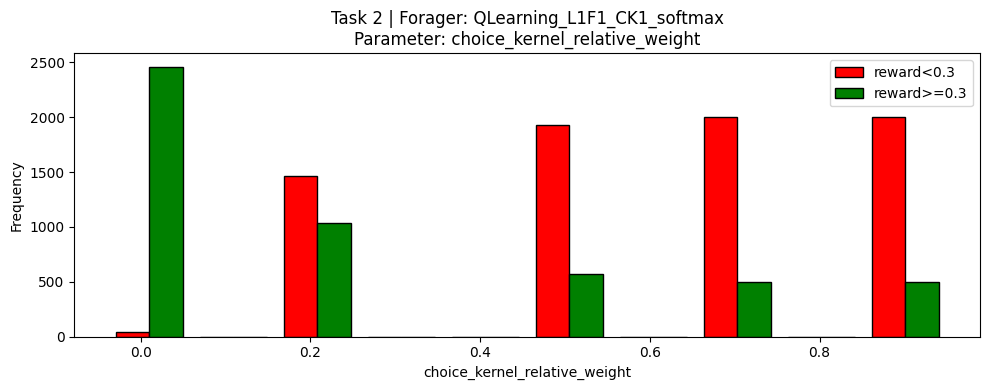

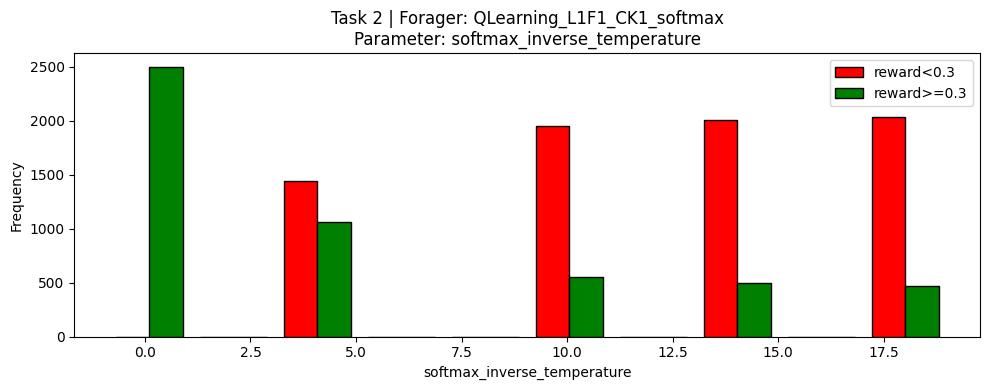

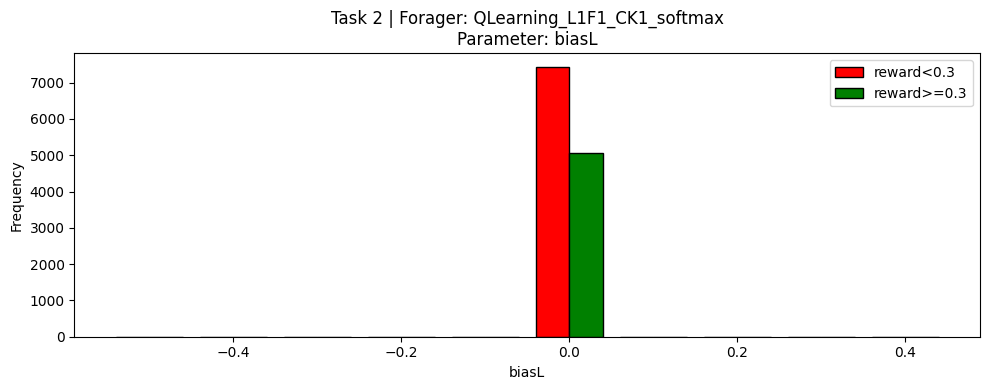

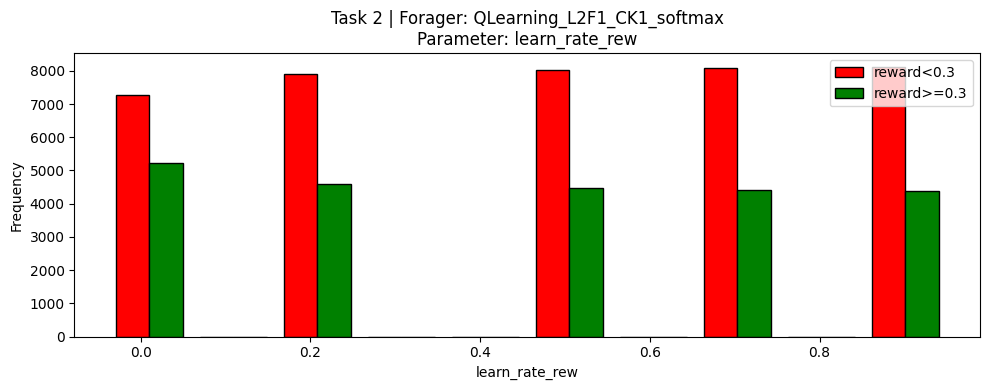

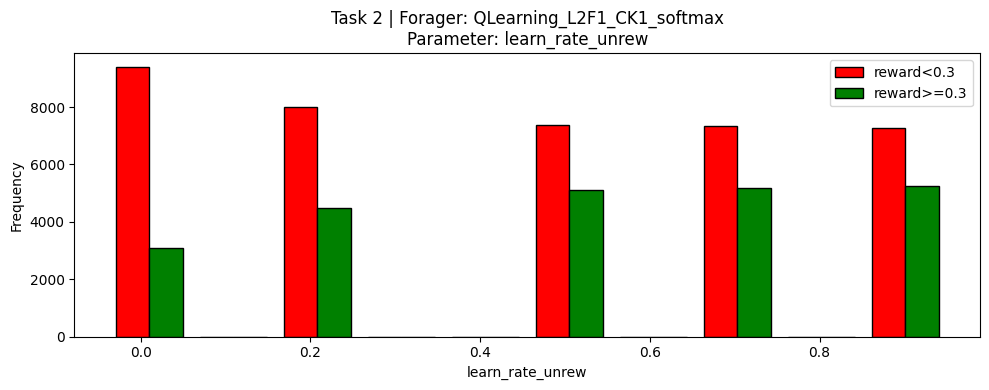

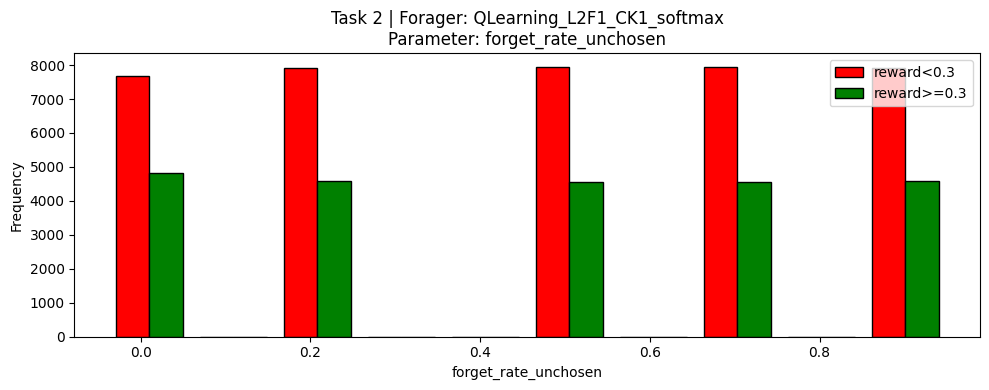

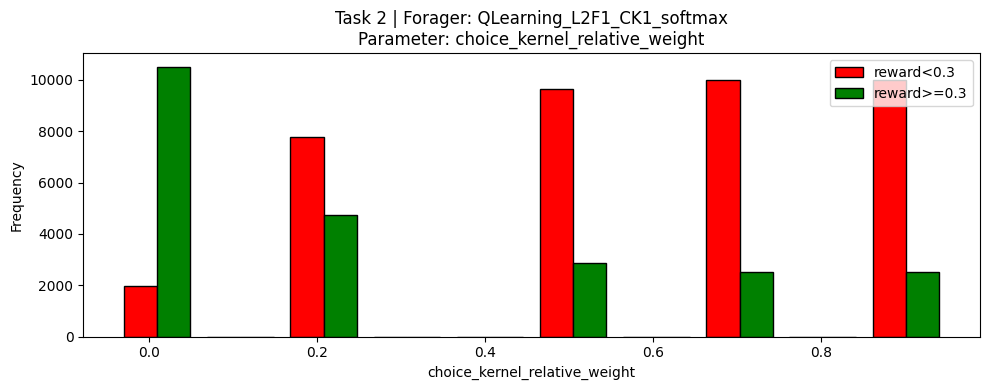

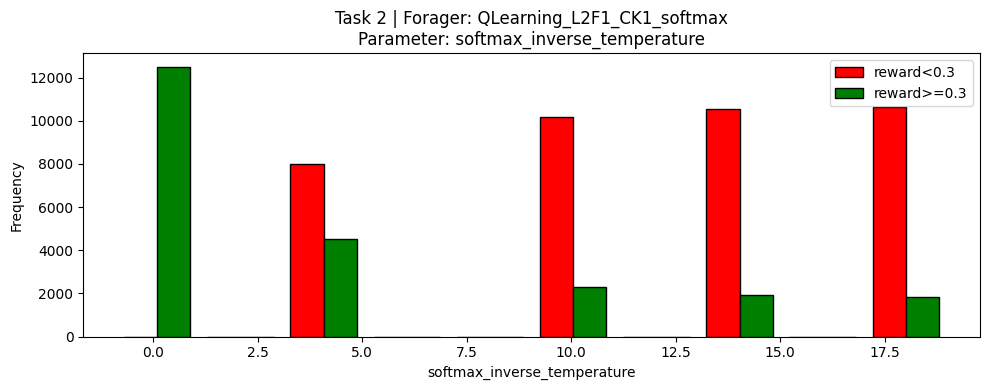

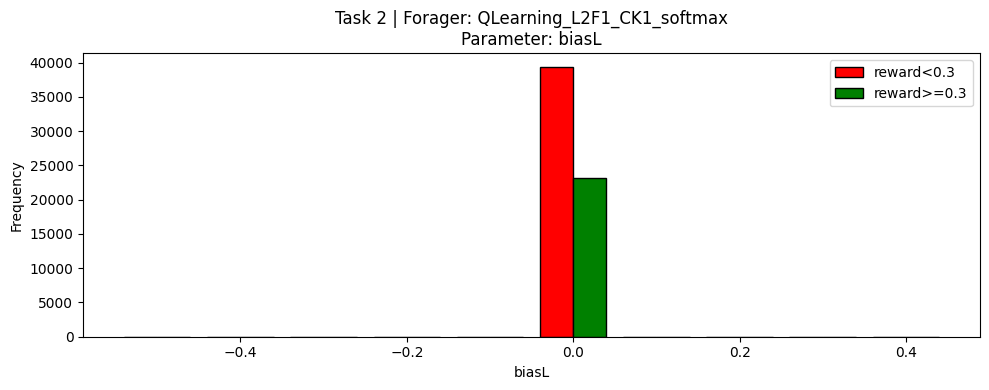

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast
from pathlib import Path

# Load CSV
csv_path = "/root/capsule/scratch/task_performance_comparison6/all_task_performance_summary.csv"
df = pd.read_csv(csv_path)

# Convert forager_params string to dict if needed
if df["forager_params"].dtype == object:
    df["forager_params"] = df["forager_params"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else {})

# Output directory
output_dir = Path("/root/capsule/scratch/forager_param_distributions")
output_dir.mkdir(parents=True, exist_ok=True)

tasks = sorted(df["task_combo_id"].unique())
foragers = sorted(df["forager_alias"].unique())
bins = 10  # histogram bins

for task in tasks:
    for forager in foragers:
        subset = df[(df["task_combo_id"] == task) & (df["forager_alias"] == forager)]
        if len(subset) == 0:
            continue

        # Split low vs high reward
        low_reward = subset[subset["agent_reward_mean"] < 0.3]
        high_reward = subset[subset["agent_reward_mean"] >= 0.3]

        # Convert forager_params to DataFrame
        low_df = pd.json_normalize(low_reward["forager_params"])
        high_df = pd.json_normalize(high_reward["forager_params"])

        all_params = low_df.columns.union(high_df.columns)

        for param in all_params:
            # Collect values
            low_vals = low_df[param].dropna().values if param in low_df.columns else np.array([])
            high_vals = high_df[param].dropna().values if param in high_df.columns else np.array([])

            if len(low_vals) == 0 and len(high_vals) == 0:
                continue  # nothing to plot

            # Compute histogram edges using combined data
            combined_vals = np.concatenate([low_vals, high_vals]) if len(low_vals) > 0 and len(high_vals) > 0 else np.concatenate([low_vals, high_vals])
            hist_bins = np.histogram_bin_edges(combined_vals, bins=bins) if len(combined_vals) > 0 else bins

            # Compute histogram counts
            low_counts, _ = np.histogram(low_vals, bins=hist_bins) if len(low_vals) > 0 else np.zeros(len(hist_bins)-1)
            high_counts, _ = np.histogram(high_vals, bins=hist_bins) if len(high_vals) > 0 else np.zeros(len(hist_bins)-1)

            width = (hist_bins[1] - hist_bins[0]) * 0.4

            plt.figure(figsize=(10, 4))
            plt.bar(hist_bins[:-1] - width/2, low_counts, width=width, color="red", label="reward<0.3", edgecolor="black")
            plt.bar(hist_bins[:-1] + width/2, high_counts, width=width, color="green", label="reward>=0.3", edgecolor="black")

            plt.title(f"Task {task} | Forager: {forager}\nParameter: {param}")
            plt.xlabel(param)
            plt.ylabel("Frequency")
            plt.legend()
            plt.tight_layout()

            # Safe filename
            safe_forager = "".join(c if c.isalnum() else "_" for c in forager)
            safe_param = "".join(c if c.isalnum() else "_" for c in param)
            fig_name = f"task_{task}_forager_{safe_forager}_{safe_param}_binned.png"

            # Save figure
            plt.savefig(output_dir / fig_name, dpi=150)
            plt.show()
            plt.close()